# Trading con FNSPID añadiendo el sentimiento de las noticias

## Autor: Eloi Serantes Abal

- Librerias utilizadas.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, GRU
from google.colab import drive
import random
import time

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
drive.mount('/content/drive')

Mounted at /content/drive


## Creación del sistema inicial

### Carga y fusión de datos

- Se conecta a internet mediante la librería yfinance para descargar el historial de precios reales de la bolsa (solo nos quedamos con el precio de Cierre o Close).

- Carga el dataset que contiene la serie temporal de sentimiento que se creó anteriormente.

- Fusión de datos (Inner Join): Cruza ambas tablas usando la fecha como llave. Si Yahoo Finance dice que el 4 de julio la bolsa estuvo cerrada por festivo, esta función elimina ese día también del sentimiento para que ambas líneas temporales encajen a la perfección

In [ ]:
def cargar_y_fusionar_datos(ticker, ruta_sentimiento, start_date="2010-01-01", end_date="2024-01-01"):
    print(f"-> Descargando precios de {ticker} desde Yahoo Finance...")
    df_precios_raw = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

    if isinstance(df_precios_raw.columns, pd.MultiIndex):
        df_precios = df_precios_raw['Close'].copy()
        if len(df_precios.columns) == 1:
            df_precios.columns = ['Close']
    else:
        df_precios = df_precios_raw[['Close']].copy()

    df_precios.index = df_precios.index.tz_localize(None)

    print("Cargando serie de sentimiento...")
    df_sentimiento = pd.read_parquet(ruta_sentimiento)
    df_sentimiento_ticker = df_sentimiento[df_sentimiento['Stock_symbol'] == ticker].copy()

    if df_sentimiento_ticker.empty:
        raise ValueError(f"No hay datos de sentimiento para el ticker {ticker}")

    df_sentimiento_ticker['Date_Only'] = pd.to_datetime(df_sentimiento_ticker['Date_Only'])
    df_sentimiento_ticker.set_index('Date_Only', inplace=True)

    print("Fusionando datasets (Inner Join)...")
    df_merged = df_precios.join(df_sentimiento_ticker[['Sentiment_Paper_Decay']], how='inner').dropna()
    print(f"Datos finales alineados: {len(df_merged)} días.")

    return df_merged

### Creación de ventanas y preparación de datos

-  Creación de Ventanas: Le pasamos un window_size de 30, esta función coge los datos y hace paquetes de 30 días.

- Preparación de datos:
  - Escalado (MinMaxScaler): Comprime todos los precios y todos los sentimientos para que estén en una escala del 0 al 1.

  - Generamos el dataset con solo precios históricos y el dataset con precios históricos y sentimiento.

  - Dividimos los datos (Train/Test): Coge el 80% inicial de los datos (los años más antiguos) para entrenar y enseñar a la IA, y se guarda el 20% final (los años más recientes) para hacerle el examen final y ver si predice bien el futuro.

In [ ]:
def crear_ventanas(data_features, data_target, window_size):
    X, y = [], []
    for i in range(len(data_features) - window_size):
        X.append(data_features[i:i + window_size])
        y.append(data_target[i + window_size])
    return np.array(X), np.array(y)

def preparar_datasets(df_merged, window_size=30):
    print(f"-> Escalando datos y creando ventanas de {window_size} días...")
    scaler_precio = MinMaxScaler(feature_range=(0, 1))
    scaler_sentimiento = MinMaxScaler(feature_range=(0, 1))

    df_merged['Close_Scaled'] = scaler_precio.fit_transform(df_merged[['Close']])
    df_merged['Sentiment_Scaled'] = scaler_sentimiento.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    # Modelo A: (Solo Precio)
    X_uni, y_uni = crear_ventanas(df_merged[['Close_Scaled']].values, df_merged['Close_Scaled'].values, window_size)

    # Modelo B: (Precio + Sentimiento)
    X_multi, _ = crear_ventanas(df_merged[['Close_Scaled', 'Sentiment_Scaled']].values, df_merged['Close_Scaled'].values, window_size)

    split = int(len(X_uni) * 0.8)

    train_data = {'X_uni': X_uni[:split], 'X_multi': X_multi[:split], 'y': y_uni[:split]}
    test_data = {'X_uni': X_uni[split:], 'X_multi': X_multi[split:], 'y': y_uni[split:]}

    return train_data, test_data, scaler_precio

### Construimos el modelo inicial para probar

- Se crea una red profunda (Sequential) con dos capas de memoria LSTM de 50 neuronas cada una.

- Se añaden capas Dropout (20%). Esto es una técnica apaga aleatoriamente algunas neuronas durante el entrenamiento para evitar que el modelo se memorice los datos de memoria (sobreajuste u overfitting) y le obliga a aprender tendencias reales.

- Termina en una capa Dense(1) que escupe un único número: el precio predicho para el día de mañana.

In [ ]:
def construir_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(50, return_sequences=True),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

### Evaluación y gráficas

- Se quita la escala del 0 al 1 para devolver los precios a dólares reales.

- Calcula el RMSE (Error Cuadrático Medio): Te dice de media por cuántos dólares se ha equivocado la predicción.

- Calcula el Hit Ratio (Dirección): A los inversores no les importa tanto clavar el precio exacto, sino saber si mañana va a subir o va a bajar. Esta métrica calcula el porcentaje de veces que el modelo acertó la tendencia (si subía y predijo que subía = acierto).

In [ ]:
def evaluar_y_graficar(model_uni, model_multi, test_data, scaler_precio, ticker):
    print("Evaluando modelos y generando métricas...")

    # Predicciones
    preds_uni = scaler_precio.inverse_transform(model_uni.predict(test_data['X_uni'], verbose=0)).flatten()
    preds_multi = scaler_precio.inverse_transform(model_multi.predict(test_data['X_multi'], verbose=0)).flatten()
    actuals = scaler_precio.inverse_transform(test_data['y'].reshape(-1, 1)).flatten()

    # Métricas RMSE
    rmse_uni = np.sqrt(mean_squared_error(actuals, preds_uni))
    rmse_multi = np.sqrt(mean_squared_error(actuals, preds_multi))

    # Métricas Hit Ratio
    last_known = scaler_precio.inverse_transform(test_data['X_uni'][:, -1, 0].reshape(-1, 1)).flatten()
    actual_dir = np.sign(actuals - last_known)
    hit_ratio_uni = np.mean(actual_dir == np.sign(preds_uni - last_known)) * 100
    hit_ratio_multi = np.mean(actual_dir == np.sign(preds_multi - last_known)) * 100

    print(f"\nRESULTADOS {ticker}:")
    print(f"Modelo A (Solo Precio)    -> RMSE: {rmse_uni:.2f} | Hit Ratio: {hit_ratio_uni:.2f}%")
    print(f"Modelo B (Precio + Sent.) -> RMSE: {rmse_multi:.2f} | Hit Ratio: {hit_ratio_multi:.2f}%")

    # Gráficas
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    dias_plot = 100

    axes[0].plot(actuals[-dias_plot:], label="Precio Real", color='black', linewidth=2)
    axes[0].plot(preds_uni[-dias_plot:], label=f"Univariante (RMSE: {rmse_uni:.2f})", color='red', linestyle='--')
    axes[0].plot(preds_multi[-dias_plot:], label=f"Multivariante (RMSE: {rmse_multi:.2f})", color='blue', linestyle='-.')
    axes[0].set_title(f"Predicción Precio Cierre {ticker} (Últimos {dias_plot} días)", fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    df_plot = pd.DataFrame({'Modelo': ['Solo Precio', 'Precio + Sentimiento'], 'Hit Ratio (%)': [hit_ratio_uni, hit_ratio_multi]})
    sns.barplot(data=df_plot, x='Modelo', y='Hit Ratio (%)', ax=axes[1], hue='Modelo', legend=False, palette=['#ff9999', '#99ccff'])
    axes[1].axhline(50, color='red', linestyle='--')
    axes[1].set_title("Precisión Direccional (Hit Ratio)", fontsize=14, fontweight='bold')
    axes[1].set_ylim(40, 70)
    for i, val in enumerate(df_plot['Hit Ratio (%)']):
        axes[1].text(i, val + 0.5, f"{val:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

## Función principal para ejecutar y entrenar el modelo

In [ ]:
def main():
    tf.keras.backend.clear_session()
    TICKER = "AAPL"
    RUTA = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    # Se cargan los datos de precios (2010 a 2023)
    df_merged = cargar_y_fusionar_datos(TICKER, RUTA, start_date="2010-01-01", end_date="2024-01-01")

    # Se prepara la ventana (30 días)
    train_data, test_data, scaler_precio = preparar_datasets(df_merged, window_size=30)

    # Se construye y entrenar modelos
    print("Entrenando Modelo Univariante...")
    modelo_uni = construir_lstm(input_shape=(30, 1))
    modelo_uni.fit(train_data['X_uni'], train_data['y'], batch_size=32, epochs=20, verbose=0)

    print("Entrenando Modelo Multivariante...")
    modelo_multi = construir_lstm(input_shape=(30, 2))
    modelo_multi.fit(train_data['X_multi'], train_data['y'], batch_size=32, epochs=20, verbose=0)

    evaluar_y_graficar(modelo_uni, modelo_multi, test_data, scaler_precio, TICKER)

[*********************100%***********************]  1 of 1 completed

-> Descargando precios de AAPL desde Yahoo Finance...
-> Cargando serie de sentimiento...


-> Fusionando datasets (Inner Join)...
Datos finales alineados: 387 días.
-> Escalando datos y creando ventanas de 30 días...
-> Entrenando Modelo Univariante...
-> Entrenando Modelo Multivariante...
-> Evaluando modelos y generando métricas...

RESULTADOS AAPL:
Modelo A (Solo Precio)    -> RMSE: 4.81 | Hit Ratio: 51.39%
Modelo B (Precio + Sent.) -> RMSE: 4.74 | Hit Ratio: 52.78%


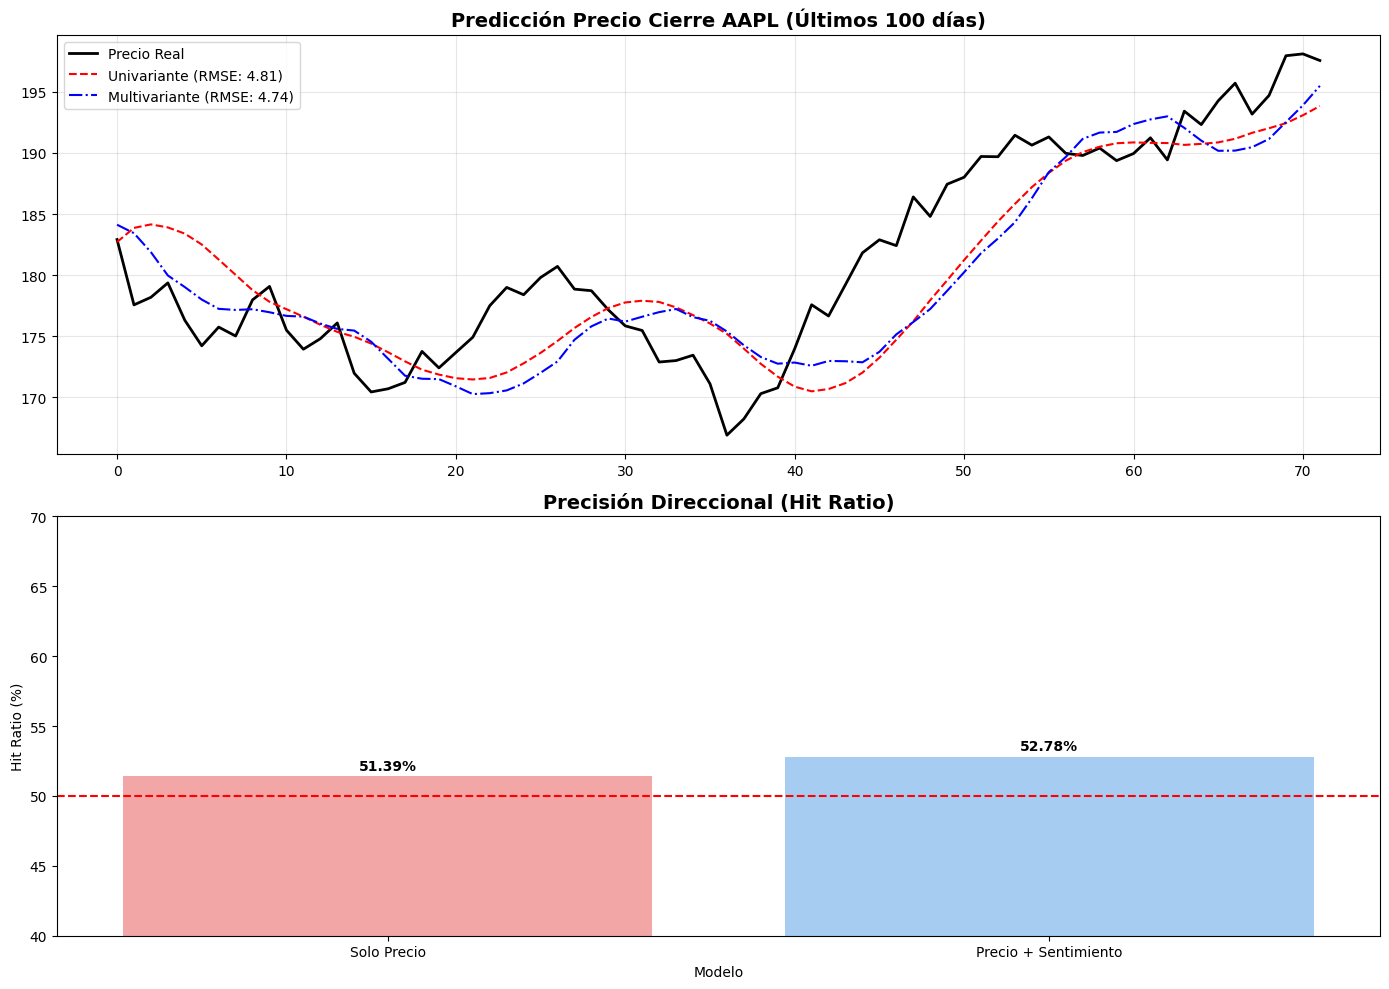

In [ ]:
if __name__ == "__main__":
    main()

Como vemos Apple tiene muy pocas noticias, vamos a mirar los ticker que tiene mayor número de noticias para ver si los resultados son más significativos.

In [ ]:
def descubrir_top_empresas():
    ruta = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'
    df = pd.read_parquet(ruta)

    top = df['Stock_symbol'].value_counts().head(5)

    print("="*40)
    print("TOP 5 EMPRESAS CON MÁS DATOS")
    print("="*40)
    print(top)

descubrir_top_empresas()

TOP 5 EMPRESAS CON MÁS DATOS
Stock_symbol
ORCL    5095
PGR     5094
TXN     5094
AIG     5094
ADI     5094
Name: count, dtype: int64


Como vemos Oracle es el ticker que más empresas tiene así que vamos a probar con él.

In [ ]:
def fijar_semillas(seed_value=42):
    """Fija la aleatoriedad para que los resultados del TFG sean reproducibles."""
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    random.seed(seed_value)

In [ ]:
def main():
    # Limpiamos memoria y fijamos semillas
    tf.keras.backend.clear_session()
    fijar_semillas(42)

    TICKER = "ORCL"
    RUTA = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    print(f"\nINICIANDO PIPELINE PARA: {TICKER}")
    df_merged = cargar_y_fusionar_datos(TICKER, RUTA, start_date="2010-01-01", end_date="2024-01-01")

    train_data, test_data, scaler_precio = preparar_datasets(df_merged, window_size=30)

    print("Entrenando Modelo Univariante...")
    modelo_uni = construir_lstm(input_shape=(30, 1))
    modelo_uni.fit(train_data['X_uni'], train_data['y'], batch_size=32, epochs=20, verbose=0)

    print("Entrenando Modelo Multivariante...")
    modelo_multi = construir_lstm(input_shape=(30, 2))
    modelo_multi.fit(train_data['X_multi'], train_data['y'], batch_size=32, epochs=20, verbose=0)

    evaluar_y_graficar(modelo_uni, modelo_multi, test_data, scaler_precio, TICKER)

[*********************100%***********************]  1 of 1 completed


INICIANDO PIPELINE PARA: ORCL
-> Descargando precios de ORCL desde Yahoo Finance...
-> Cargando serie de sentimiento...


-> Fusionando datasets (Inner Join)...
Datos finales alineados: 3513 días.
-> Escalando datos y creando ventanas de 30 días...
-> Entrenando Modelo Univariante...
-> Entrenando Modelo Multivariante...
-> Evaluando modelos y generando métricas...

RESULTADOS ORCL:
Modelo A (Solo Precio)    -> RMSE: 2.75 | Hit Ratio: 47.92%
Modelo B (Precio + Sent.) -> RMSE: 3.14 | Hit Ratio: 47.20%


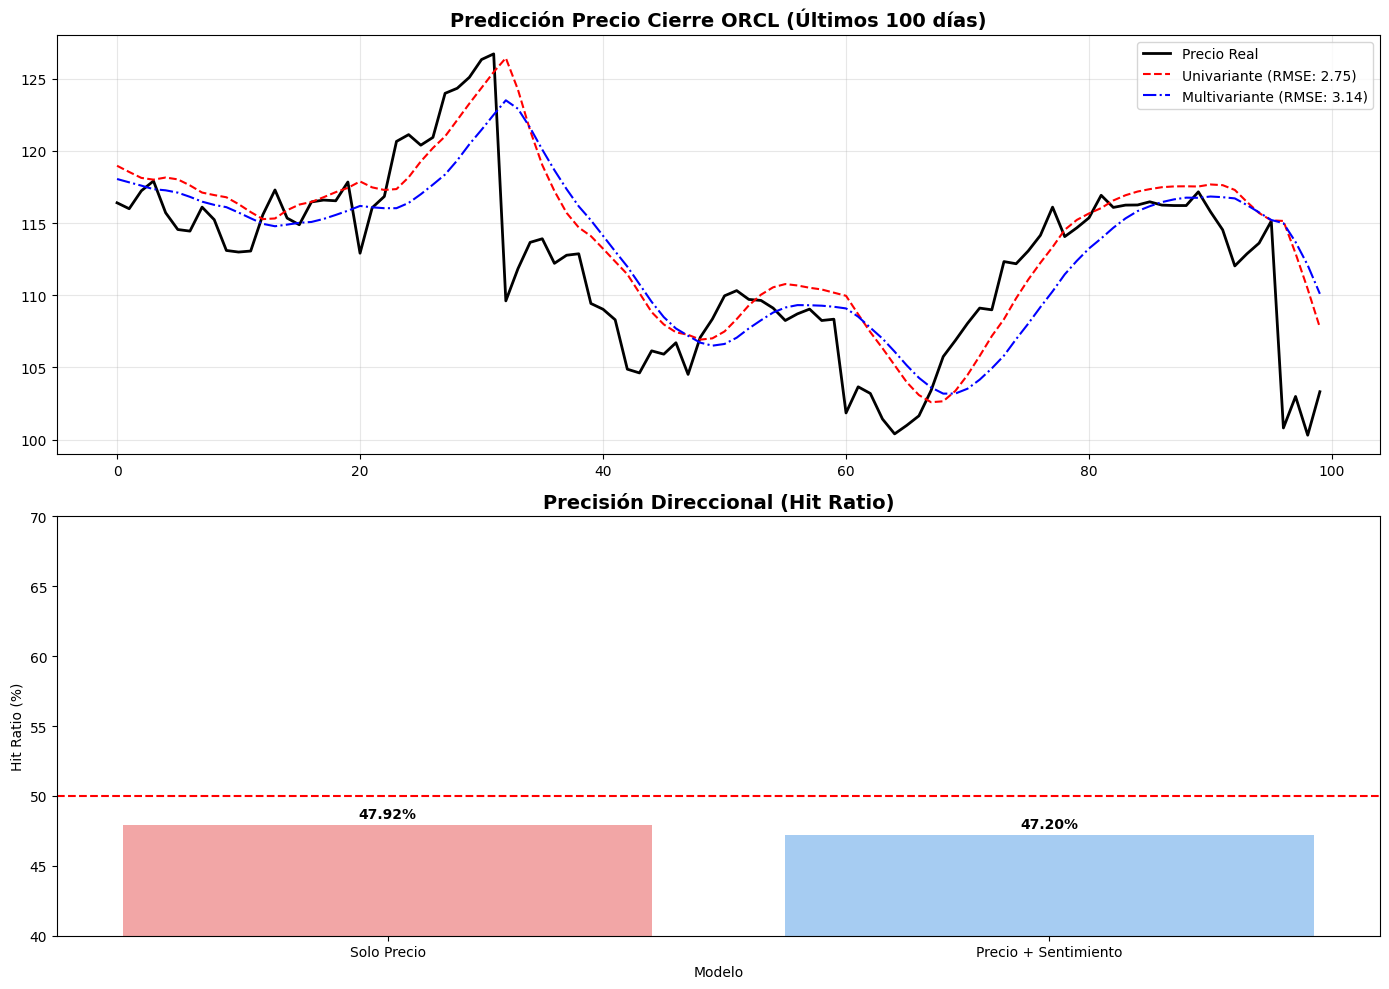

In [ ]:
main()

Al intentar predecir el Precio de Cierre directamente, descubrimos que la red neuronal LSTM tendía a copiar el precio del día anterior para minimizar el error absoluto, lo que anulaba la utilidad de nuestra variable de sentimiento.

Para evitar esa trampa, decidimos entrenar al modelo usando los Retornos Logarítmicos. Esto obliga a la Inteligencia Artificial a predecir la variación real del mercado, donde el sentimiento de las noticias (FinBERT) tiene la oportunidad de brillar.

Una vez que el modelo predice el retorno, aplicamos una reconstrucción matemática inversa para devolverle el formato original y presentar la predicción final en el Precio de Cierre ($)

### Probamos a usar retornos logarítmicos

In [ ]:
ticker = "ORCL"
ruta_sentimiento = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

# Descargamos de precios de Yahoo Finance
df_precios_raw = yf.download(ticker, start="2010-01-01", end="2024-01-01", auto_adjust=False)

# Ajuste por si yfinance devuelve MultiIndex
if isinstance(df_precios_raw.columns, pd.MultiIndex):
    df_precios = df_precios_raw['Close'].copy()
    if len(df_precios.columns) == 1: df_precios.columns = ['Close']
else:
    df_precios = df_precios_raw[['Close']].copy()

df_precios.index = df_precios.index.tz_localize(None)

# Convertimos el Precio a Retorno Logarítmico
df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
df_precios.dropna(inplace=True)

# Cargar el sentimiento y cruzamos las tablas
df_sent = pd.read_parquet(ruta_sentimiento)
df_sent = df_sent[df_sent['Stock_symbol'] == ticker].copy()
df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
df_sent.set_index('Date_Only', inplace=True)

df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()

print(f"Datos alineados: {len(df_merged)} días.")
display(df_merged.head())

[*********************100%***********************]  1 of 1 completed


Datos alineados: 3512 días.


,Close,Log_Ret,Sentiment_Paper_Decay
2010-01-05,24.820000,-0.001208,0.712878
2010-01-06,24.459999,-0.014611,0.691809
2010-01-07,24.379999,-0.003276,0.671363
2010-01-08,24.680000,0.012230,0.651521
2010-01-11,24.690001,0.000405,0.595446


In [ ]:
window_size = 30

scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
scaler_sent = MinMaxScaler(feature_range=(-1, 1))

df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

def crear_ventanas(data_x, data_y, window):
    X, y = [], []
    for i in range(len(data_x) - window):
        X.append(data_x[i:i + window])
        y.append(data_y[i + window])
    return np.array(X), np.array(y)

# Dataset Univariante (Solo el retorno del mercado)
X_uni, y_uni = crear_ventanas(df_merged[['Ret_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)

# Dataset Multivariante (Retorno del mercado + Sentimiento de las noticias)
X_multi, _ = crear_ventanas(df_merged[['Ret_Scaled', 'Sent_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)

# Partimos en Train (80%) y Test (20%)
split = int(len(X_uni) * 0.8)
X_train_u, X_test_u = X_uni[:split], X_uni[split:]
X_train_m, X_test_m = X_multi[:split], X_multi[split:]
y_train, y_test = y_uni[:split], y_uni[split:]

print(f"Ventanas creadas. Para entrenar: {len(X_train_u)}. Para testear: {len(X_test_u)}.")

Ventanas creadas. Para entrenar: 2785. Para testear: 697.


In [ ]:
def crear_modelo_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(50, return_sequences=True), Dropout(0.2),
        LSTM(50, return_sequences=False), Dropout(0.2),
        Dense(25), Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

print("Entrenando Modelo A (Solo Retornos)...")
modelo_uni = crear_modelo_lstm((window_size, 1))
modelo_uni.fit(X_train_u, y_train, batch_size=32, epochs=20, verbose=0)

print("Entrenando Modelo B (Retornos + Sentimiento)...")
modelo_multi = crear_modelo_lstm((window_size, 2))
modelo_multi.fit(X_train_m, y_train, batch_size=32, epochs=20, verbose=0)

Entrenando Modelo A (Solo Retornos)... esto tardará un minuto.
Entrenando Modelo B (Retornos + Sentimiento)...
¡Ambos modelos han terminado de entrenar!


RESULTADOS ORCL (RETORNOS LOGARÍTMICOS):
Modelo Solo Retornos    -> RMSE: 0.0190 | Hit Ratio: 52.22%
Modelo Retornos + Sent. -> RMSE: 0.0190 | Hit Ratio: 52.22%


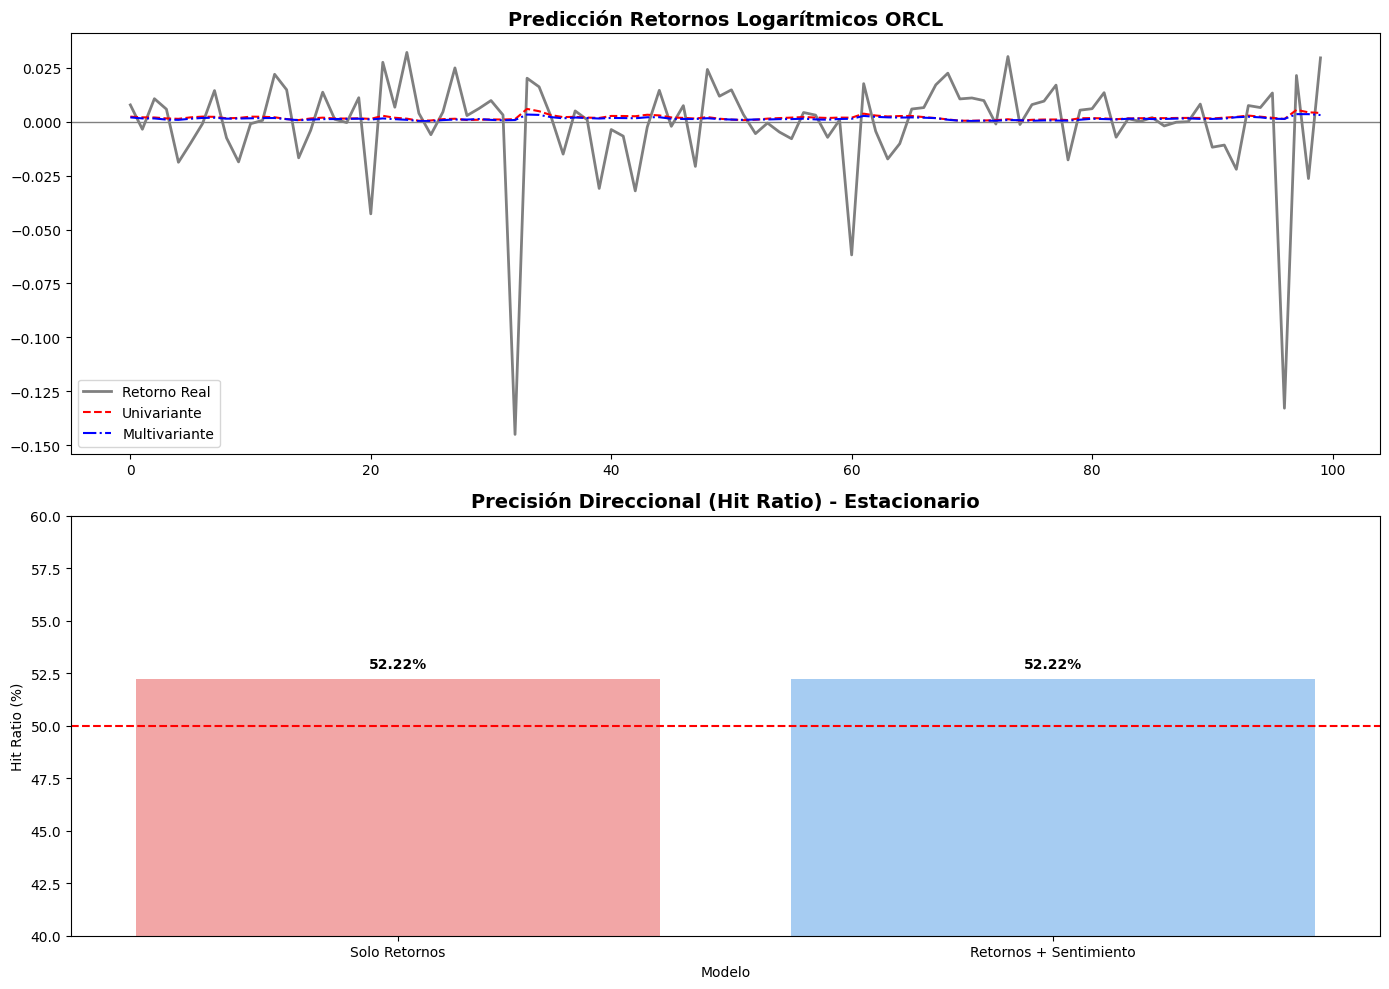

In [ ]:
preds_uni = scaler_retorno.inverse_transform(modelo_uni.predict(X_test_u, verbose=0)).flatten()
preds_multi = scaler_retorno.inverse_transform(modelo_multi.predict(X_test_m, verbose=0)).flatten()
actuals = scaler_retorno.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Calculamos RMSE
rmse_uni = np.sqrt(mean_squared_error(actuals, preds_uni))
rmse_multi = np.sqrt(mean_squared_error(actuals, preds_multi))

# Calculamos Hit Ratio
hit_ratio_uni = np.mean(np.sign(actuals) == np.sign(preds_uni)) * 100
hit_ratio_multi = np.mean(np.sign(actuals) == np.sign(preds_multi)) * 100

print("="*50)
print(f"RESULTADOS ORCL (RETORNOS LOGARÍTMICOS):")
print(f"Modelo Solo Retornos    -> RMSE: {rmse_uni:.4f} | Hit Ratio: {hit_ratio_uni:.2f}%")
print(f"Modelo Retornos + Sent. -> RMSE: {rmse_multi:.4f} | Hit Ratio: {hit_ratio_multi:.2f}%")
print("="*50)

# Gráficas
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
dias_plot = 100

axes[0].plot(actuals[-dias_plot:], label="Retorno Real", color='black', alpha=0.5, linewidth=2)
axes[0].plot(preds_uni[-dias_plot:], label=f"Univariante", color='red', linestyle='--')
axes[0].plot(preds_multi[-dias_plot:], label=f"Multivariante", color='blue', linestyle='-.')
axes[0].axhline(0, color='gray', linestyle='-', linewidth=1)
axes[0].set_title(f"Predicción Retornos Logarítmicos {ticker}", fontsize=14, fontweight='bold')
axes[0].legend()

df_plot = pd.DataFrame({'Modelo': ['Solo Retornos', 'Retornos + Sentimiento'], 'Hit Ratio (%)': [hit_ratio_uni, hit_ratio_multi]})
sns.barplot(data=df_plot, x='Modelo', y='Hit Ratio (%)', ax=axes[1], hue='Modelo', legend=False, palette=['#ff9999', '#99ccff'])
axes[1].axhline(50, color='red', linestyle='--')
axes[1].set_title("Precisión Direccional (Hit Ratio) - Estacionario", fontsize=14, fontweight='bold')
axes[1].set_ylim(40, 60)
for i, val in enumerate(df_plot['Hit Ratio (%)']):
    axes[1].text(i, val + 0.5, f"{val:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

- Se prueban en empresas más volátiles

In [ ]:
def revisar_noticias_volatiles():
    ruta = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'
    df = pd.read_parquet(ruta)

    empresas_interes = ['TSLA', 'NVDA', 'META', 'AMZN', 'NFLX', 'AAPL']

    df_filtrado = df[df['Stock_symbol'].isin(empresas_interes)]

    conteo = df_filtrado['Stock_symbol'].value_counts()

    print("="*55)
    print("DÍAS DE HISTORIAL PARA EMPRESAS VOLÁTILES (S&P 500)")
    print("="*55)
    print(conteo)

revisar_noticias_volatiles()

DÍAS DE HISTORIAL PARA EMPRESAS VOLÁTILES (S&P 500)
Stock_symbol
NVDA    852
TSLA    594
AAPL    562
AMZN    283
Name: count, dtype: int64


[*********************100%***********************]  1 of 1 completed

INICIANDO PRUEBA DEFINITIVA: NVDA (Retornos -> Precios)


Datos alineados: 588 días.
⏳ Entrenando Modelo Univariante...
⏳ Entrenando Modelo Multivariante (con FinBERT)...

RESULTADOS FINALES NVDA (Precios Reconstruidos)
Modelo Solo Histórico -> RMSE: $1.08 | Hit Ratio: 56.25%
Modelo + Sentimiento  -> RMSE: $1.06 | Hit Ratio: 55.36%


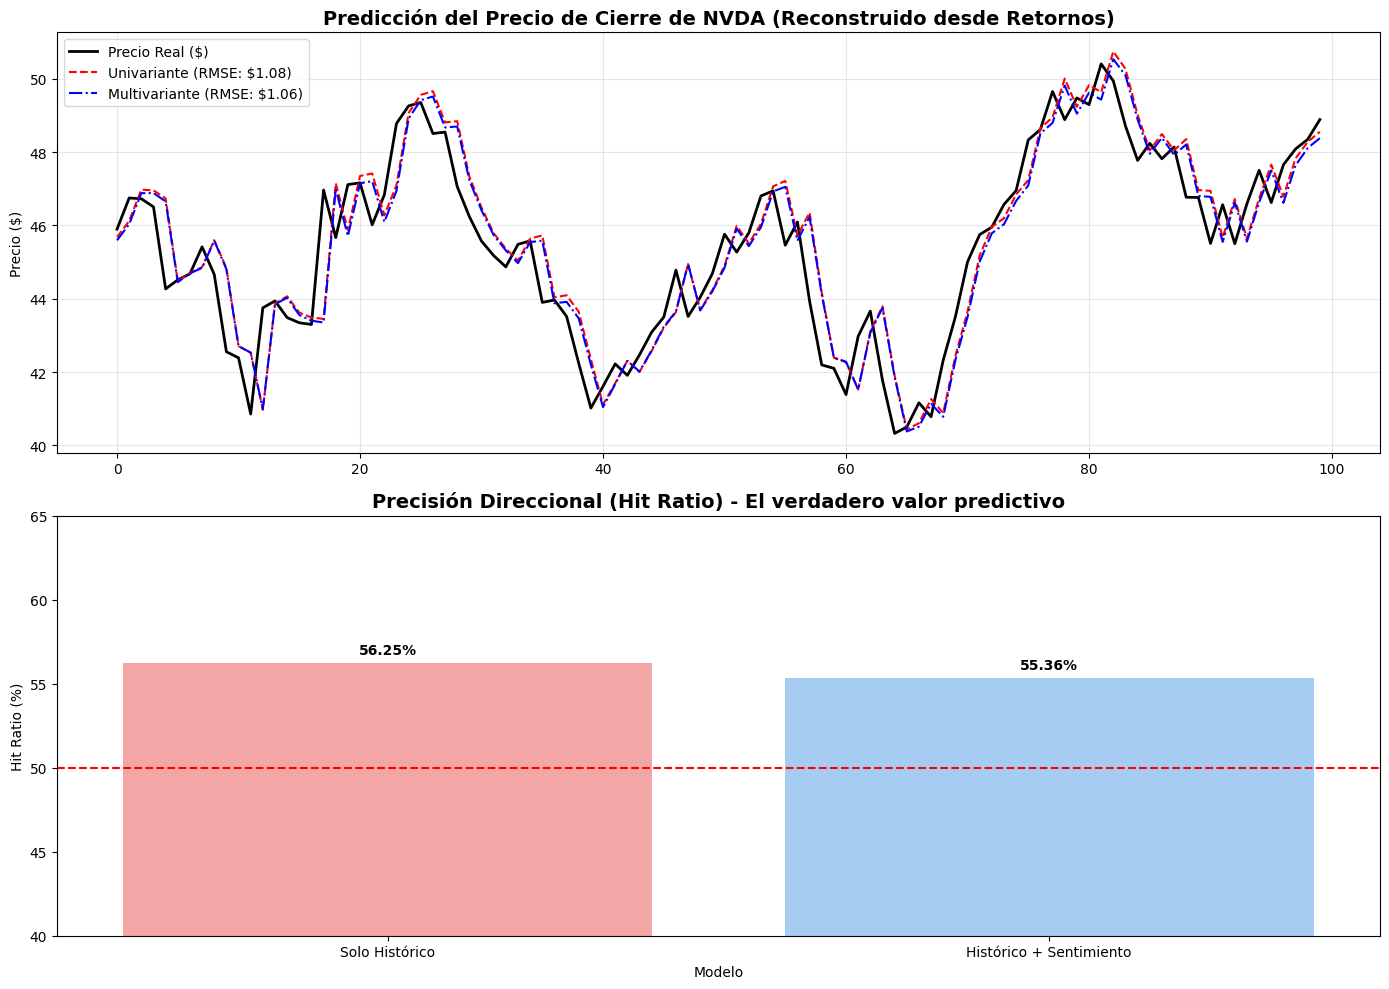

In [ ]:
def prueba_definitiva_nvda():
    # Preparación y Semillas
    tf.keras.backend.clear_session()
    np.random.seed(42)
    tf.random.set_seed(42)
    random.seed(42)

    TICKER = "NVDA"
    RUTA = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'
    window_size = 30

    print(f"INICIANDO PRUEBA DEFINITIVA: {TICKER} (Retornos -> Precios)")

    # Descarga y cálculo de Retornos
    df_precios_raw = yf.download(TICKER, start="2010-01-01", end="2024-01-01", auto_adjust=False)
    if isinstance(df_precios_raw.columns, pd.MultiIndex):
        df_precios = df_precios_raw['Close'].copy()
        if len(df_precios.columns) == 1: df_precios.columns = ['Close']
    else:
        df_precios = df_precios_raw[['Close']].copy()

    df_precios.index = df_precios.index.tz_localize(None)
    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    # Fusión con Sentimiento
    df_sent = pd.read_parquet(RUTA)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()
    print(f"Datos alineados: {len(df_merged)} días.")

    # Escalado y Ventanas Temporales
    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))

    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas(data_x, data_y, window):
        X, y = [], []
        for i in range(len(data_x) - window):
            X.append(data_x[i:i + window])
            y.append(data_y[i + window])
        return np.array(X), np.array(y)

    X_uni, y_uni = crear_ventanas(df_merged[['Ret_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)
    X_multi, _ = crear_ventanas(df_merged[['Ret_Scaled', 'Sent_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)

    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]
    y_train, y_test = y_uni[:split], y_uni[split:]

    # Entrenamiento
    def crear_modelo_lstm(input_shape):
        model = Sequential([
            Input(shape=input_shape),
            LSTM(50, return_sequences=True), Dropout(0.2),
            LSTM(50, return_sequences=False), Dropout(0.2),
            Dense(25), Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        return model

    print("Entrenando Modelo Univariante...")
    modelo_uni = crear_modelo_lstm((window_size, 1))
    modelo_uni.fit(X_train_u, y_train, batch_size=32, epochs=20, verbose=0)

    print("Entrenando Modelo Multivariante (con FinBERT)...")
    modelo_multi = crear_modelo_lstm((window_size, 2))
    modelo_multi.fit(X_train_m, y_train, batch_size=32, epochs=20, verbose=0)

    # Predicciones y reconstrucción matemática a precio.
    preds_ret_uni = scaler_retorno.inverse_transform(modelo_uni.predict(X_test_u, verbose=0)).flatten()
    preds_ret_multi = scaler_retorno.inverse_transform(modelo_multi.predict(X_test_m, verbose=0)).flatten()
    actual_ret = scaler_retorno.inverse_transform(y_test.reshape(-1, 1)).flatten()

    precios_reales = df_merged['Close'].values
    precios_base = precios_reales[-(len(preds_ret_uni)+1):-1]
    precio_real_target = precios_reales[-len(preds_ret_uni):]

    precio_pred_uni = precios_base * np.exp(preds_ret_uni)
    precio_pred_multi = precios_base * np.exp(preds_ret_multi)

    rmse_uni = np.sqrt(mean_squared_error(precio_real_target, precio_pred_uni))
    rmse_multi = np.sqrt(mean_squared_error(precio_real_target, precio_pred_multi))

    hit_ratio_uni = np.mean(np.sign(actual_ret) == np.sign(preds_ret_uni)) * 100
    hit_ratio_multi = np.mean(np.sign(actual_ret) == np.sign(preds_ret_multi)) * 100

    print("\n" + "="*50)
    print(f"RESULTADOS FINALES {TICKER} (Precios Reconstruidos)")
    print(f"Modelo Solo Histórico -> RMSE: ${rmse_uni:.2f} | Hit Ratio: {hit_ratio_uni:.2f}%")
    print(f"Modelo + Sentimiento  -> RMSE: ${rmse_multi:.2f} | Hit Ratio: {hit_ratio_multi:.2f}%")
    print("="*50)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    dias_plot = 100

    axes[0].plot(precio_real_target[-dias_plot:], label="Precio Real ($)", color='black', linewidth=2)
    axes[0].plot(precio_pred_uni[-dias_plot:], label=f"Univariante (RMSE: ${rmse_uni:.2f})", color='red', linestyle='--')
    axes[0].plot(precio_pred_multi[-dias_plot:], label=f"Multivariante (RMSE: ${rmse_multi:.2f})", color='blue', linestyle='-.')
    axes[0].set_title(f"Predicción del Precio de Cierre de {TICKER} (Reconstruido desde Retornos)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Precio ($)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    df_plot = pd.DataFrame({'Modelo': ['Solo Histórico', 'Histórico + Sentimiento'], 'Hit Ratio (%)': [hit_ratio_uni, hit_ratio_multi]})
    sns.barplot(data=df_plot, x='Modelo', y='Hit Ratio (%)', ax=axes[1], hue='Modelo', legend=False, palette=['#ff9999', '#99ccff'])
    axes[1].axhline(50, color='red', linestyle='--', label="Aleatorio (50%)")
    axes[1].set_title("Precisión Direccional (Hit Ratio) - El verdadero valor predictivo", fontsize=14, fontweight='bold')
    axes[1].set_ylim(40, 65)
    for i, val in enumerate(df_plot['Hit Ratio (%)']):
        axes[1].text(i, val + 0.5, f"{val:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

prueba_definitiva_nvda()

In [ ]:
def prueba_retornos(ticker_elegido):
    # Preparación y Semillas
    tf.keras.backend.clear_session()
    np.random.seed(42)
    tf.random.set_seed(42)
    random.seed(42)

    TICKER = ticker_elegido
    RUTA = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'
    window_size = 30

    print(f"INICIANDO PRUEBA: {TICKER} (Retornos -> Precios)")

    # Descarga y cálculo de Retornos
    df_precios_raw = yf.download(TICKER, start="2010-01-01", end="2024-01-01", auto_adjust=False)
    if isinstance(df_precios_raw.columns, pd.MultiIndex):
        df_precios = df_precios_raw['Close'].copy()
        if len(df_precios.columns) == 1: df_precios.columns = ['Close']
    else:
        df_precios = df_precios_raw[['Close']].copy()

    df_precios.index = df_precios.index.tz_localize(None)
    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    # Fusión con Sentimiento
    df_sent = pd.read_parquet(RUTA)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()
    print(f"Datos alineados: {len(df_merged)} días.")

    # Escalado y Ventanas Temporales
    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))

    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas(data_x, data_y, window):
        X, y = [], []
        for i in range(len(data_x) - window):
            X.append(data_x[i:i + window])
            y.append(data_y[i + window])
        return np.array(X), np.array(y)

    X_uni, y_uni = crear_ventanas(df_merged[['Ret_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)
    X_multi, _ = crear_ventanas(df_merged[['Ret_Scaled', 'Sent_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)

    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]
    y_train, y_test = y_uni[:split], y_uni[split:]

    # Entrenamiento
    def crear_modelo_lstm(input_shape):
        model = Sequential([
            Input(shape=input_shape),
            LSTM(50, return_sequences=True), Dropout(0.2),
            LSTM(50, return_sequences=False), Dropout(0.2),
            Dense(25), Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        return model

    print("Entrenando Modelo Univariante...")
    modelo_uni = crear_modelo_lstm((window_size, 1))
    modelo_uni.fit(X_train_u, y_train, batch_size=32, epochs=20, verbose=0)

    print("Entrenando Modelo Multivariante (con FinBERT)...")
    modelo_multi = crear_modelo_lstm((window_size, 2))
    modelo_multi.fit(X_train_m, y_train, batch_size=32, epochs=20, verbose=0)

    # Predicciones y Reconstrucción a precio.
    preds_ret_uni = scaler_retorno.inverse_transform(modelo_uni.predict(X_test_u, verbose=0)).flatten()
    preds_ret_multi = scaler_retorno.inverse_transform(modelo_multi.predict(X_test_m, verbose=0)).flatten()
    actual_ret = scaler_retorno.inverse_transform(y_test.reshape(-1, 1)).flatten()

    precios_reales = df_merged['Close'].values
    precios_base = precios_reales[-(len(preds_ret_uni)+1):-1]
    precio_real_target = precios_reales[-len(preds_ret_uni):]

    precio_pred_uni = precios_base * np.exp(preds_ret_uni)
    precio_pred_multi = precios_base * np.exp(preds_ret_multi)

    # Calculamos RMSE
    rmse_uni = np.sqrt(mean_squared_error(precio_real_target, precio_pred_uni))
    rmse_multi = np.sqrt(mean_squared_error(precio_real_target, precio_pred_multi))

    # Calculamos Hit Ratio
    hit_ratio_uni = np.mean(np.sign(actual_ret) == np.sign(preds_ret_uni)) * 100
    hit_ratio_multi = np.mean(np.sign(actual_ret) == np.sign(preds_ret_multi)) * 100

    print("\n" + "="*50)
    print(f"RESULTADOS FINALES {TICKER} (Precios Reconstruidos)")
    print(f"Modelo Solo Histórico -> RMSE: ${rmse_uni:.2f} | Hit Ratio: {hit_ratio_uni:.2f}%")
    print(f"Modelo + Sentimiento  -> RMSE: ${rmse_multi:.2f} | Hit Ratio: {hit_ratio_multi:.2f}%")
    print("="*50)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    dias_plot = 100

    axes[0].plot(precio_real_target[-dias_plot:], label="Precio Real ($)", color='black', linewidth=2)
    axes[0].plot(precio_pred_uni[-dias_plot:], label=f"Univariante (RMSE: ${rmse_uni:.2f})", color='red', linestyle='--')
    axes[0].plot(precio_pred_multi[-dias_plot:], label=f"Multivariante (RMSE: ${rmse_multi:.2f})", color='blue', linestyle='-.')
    axes[0].set_title(f"Predicción del Precio de Cierre de {TICKER} (Reconstruido desde Retornos)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Precio ($)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    df_plot = pd.DataFrame({'Modelo': ['Solo Histórico', 'Histórico + Sentimiento'], 'Hit Ratio (%)': [hit_ratio_uni, hit_ratio_multi]})
    sns.barplot(data=df_plot, x='Modelo', y='Hit Ratio (%)', ax=axes[1], hue='Modelo', legend=False, palette=['#ff9999', '#99ccff'])
    axes[1].axhline(50, color='red', linestyle='--', label="Aleatorio (50%)")
    axes[1].set_title("Precisión Direccional (Hit Ratio) - El verdadero valor predictivo", fontsize=14, fontweight='bold')
    axes[1].set_ylim(40, 65)
    for i, val in enumerate(df_plot['Hit Ratio (%)']):
        axes[1].text(i, val + 0.5, f"{val:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

🚀 INICIANDO PRUEBA DEFINITIVA: AAPL (Retornos -> Precios)


[*********************100%***********************]  1 of 1 completed


Datos alineados: 387 días.
Entrenando Modelo Univariante...
Entrenando Modelo Multivariante (con FinBERT)...

RESULTADOS FINALES AAPL (Precios Reconstruidos)
Modelo Solo Histórico -> RMSE: $2.16 | Hit Ratio: 56.94%
Modelo + Sentimiento  -> RMSE: $2.19 | Hit Ratio: 54.17%


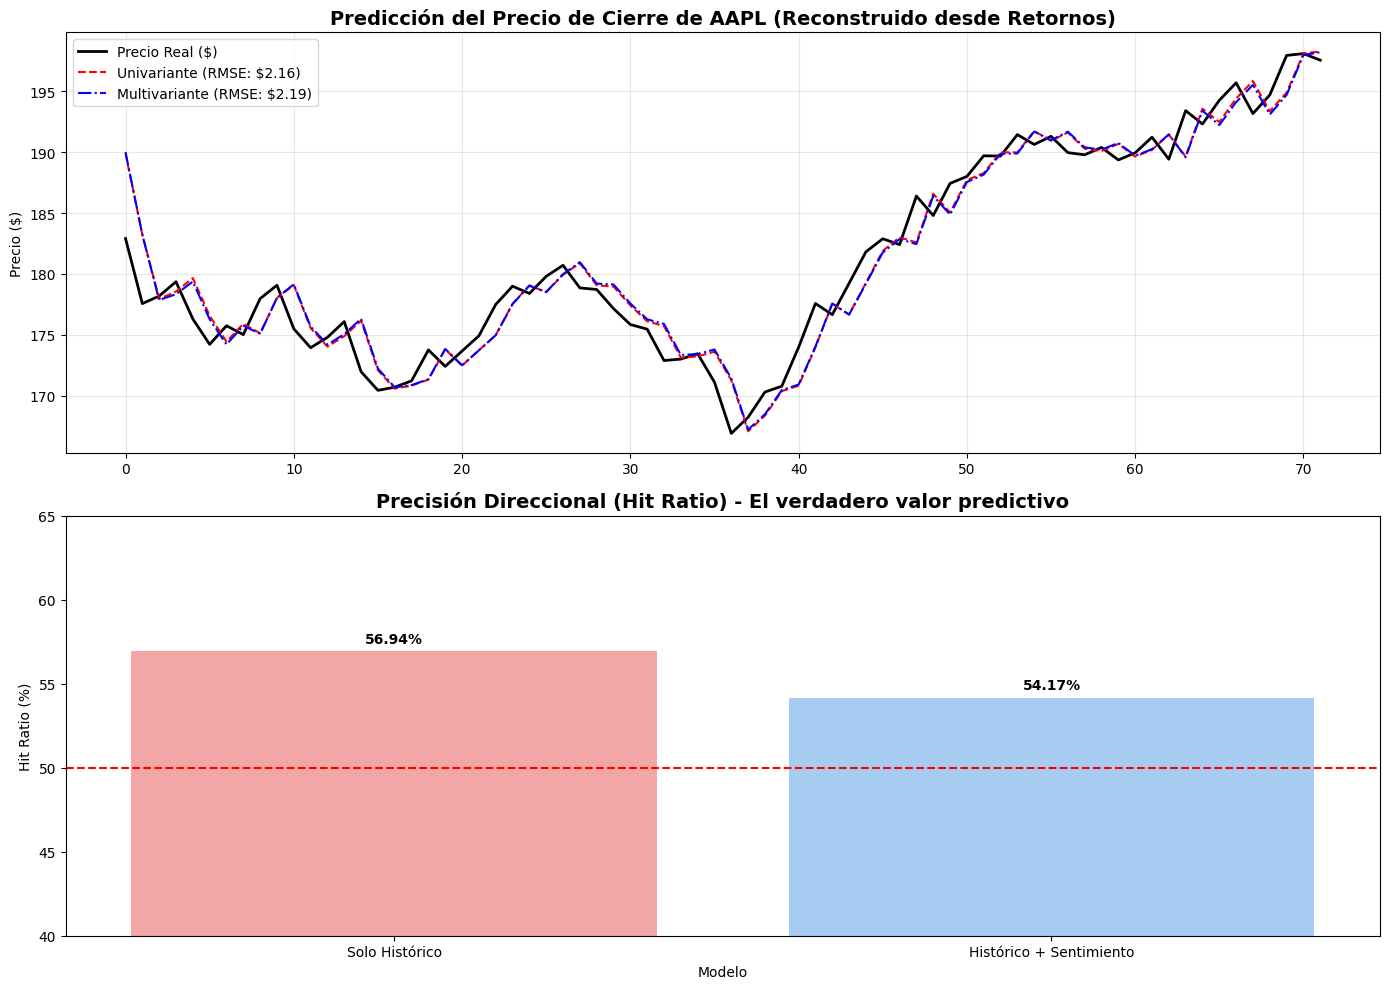

In [ ]:
prueba_retornos("AAPL")

### Probamos con GRU

- Con Apple y Nvidia.

In [ ]:
def prueba_retornos_gru(ticker_elegido):
    tf.keras.backend.clear_session()
    np.random.seed(42)
    tf.random.set_seed(42)
    random.seed(42)

    TICKER = ticker_elegido
    RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'
    window_size = 30

    print(f"INICIANDO EXPERIMENTO GRU: {TICKER}")

    df_precios_raw = yf.download(TICKER, start="2010-01-01", end="2024-01-01", auto_adjust=False)

    if isinstance(df_precios_raw.columns, pd.MultiIndex):
        df_precios = df_precios_raw['Close'].copy()
        if len(df_precios.columns) == 1: df_precios.columns = ['Close']
    else:
        df_precios = df_precios_raw[['Close']].copy()

    df_precios.index = df_precios.index.tz_localize(None)

    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    df_sent = pd.read_parquet(RUTA_SENTIMIENTO)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()
    print(f"Datos alineados para {TICKER}: {len(df_merged)} días bursátiles.")

    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))

    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas(data_x, data_y, window):
        X, y = [], []
        for i in range(len(data_x) - window):
            X.append(data_x[i:i + window])
            y.append(data_y[i + window])
        return np.array(X), np.array(y)

    X_uni, y_uni = crear_ventanas(df_merged[['Ret_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)
    X_multi, _ = crear_ventanas(df_merged[['Ret_Scaled', 'Sent_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)

    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]
    y_train, y_test = y_uni[:split], y_uni[split:]

    def crear_modelo_gru(input_shape):
        model = Sequential([
            Input(shape=input_shape),
            GRU(50, return_sequences=True), Dropout(0.2),
            GRU(50, return_sequences=False), Dropout(0.2),
            Dense(25), Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        return model

    print("Entrenando GRU Univariante...")
    modelo_uni = crear_modelo_gru((window_size, 1))
    modelo_uni.fit(X_train_u, y_train, batch_size=32, epochs=20, verbose=0)

    print("Entrenando GRU Multivariante...")
    modelo_multi = crear_modelo_gru((window_size, 2))
    modelo_multi.fit(X_train_m, y_train, batch_size=32, epochs=20, verbose=0)

    preds_ret_uni = scaler_retorno.inverse_transform(modelo_uni.predict(X_test_u, verbose=0)).flatten()
    preds_ret_multi = scaler_retorno.inverse_transform(modelo_multi.predict(X_test_m, verbose=0)).flatten()
    actual_ret = scaler_retorno.inverse_transform(y_test.reshape(-1, 1)).flatten()

    precios_reales = df_merged['Close'].values
    precios_ayer = precios_reales[-(len(preds_ret_uni)+1):-1]
    precio_real_hoy = precios_reales[-len(preds_ret_uni):]

    precio_pred_uni = precios_ayer * np.exp(preds_ret_uni)
    precio_pred_multi = precios_ayer * np.exp(preds_ret_multi)

    rmse_uni = np.sqrt(mean_squared_error(precio_real_hoy, precio_pred_uni))
    rmse_multi = np.sqrt(mean_squared_error(precio_real_hoy, precio_pred_multi))

    hit_ratio_uni = np.mean(np.sign(actual_ret) == np.sign(preds_ret_uni)) * 100
    hit_ratio_multi = np.mean(np.sign(actual_ret) == np.sign(preds_ret_multi)) * 100

    print("\n" + "="*55)
    print(f"RESULTADOS FINALES {TICKER} (Arquitectura GRU)")
    print(f"Modelo Solo Histórico -> RMSE: ${rmse_uni:.2f} | Hit Ratio: {hit_ratio_uni:.2f}%")
    print(f"Modelo + Sentimiento  -> RMSE: ${rmse_multi:.2f} | Hit Ratio: {hit_ratio_multi:.2f}%")
    print("="*55)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    dias_plot = 100

    axes[0].plot(precio_real_hoy[-dias_plot:], label="Precio Real ($)", color='black', linewidth=2)
    axes[0].plot(precio_pred_uni[-dias_plot:], label=f"Solo Histórico (RMSE: ${rmse_uni:.2f})", color='red', linestyle='--')
    axes[0].plot(precio_pred_multi[-dias_plot:], label=f"Histórico + Sentimiento (RMSE: ${rmse_multi:.2f})", color='blue', linestyle='-.')
    axes[0].set_title(f"Predicción del Precio de Cierre ({TICKER}) - Reconstrucción desde Retornos (GRU)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Precio en Dólares ($)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    df_plot = pd.DataFrame({
        'Modelo': ['Solo Histórico', 'Histórico + Sentimiento'],
        'Hit Ratio (%)': [hit_ratio_uni, hit_ratio_multi]
    })
    sns.barplot(data=df_plot, x='Modelo', y='Hit Ratio (%)', ax=axes[1], hue='Modelo', legend=False, palette=['#ff9999', '#99ccff'])
    axes[1].axhline(50, color='red', linestyle='--', label="Nivel Aleatorio (50%)")
    axes[1].set_title("Precisión Direccional (Hit Ratio)", fontsize=14, fontweight='bold')
    axes[1].set_ylim(40, 65)
    for i, val in enumerate(df_plot['Hit Ratio (%)']):
        axes[1].text(i, val + 0.5, f"{val:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

[*********************100%***********************]  1 of 1 completed

INICIANDO EXPERIMENTO GRU: AAPL


Datos alineados para AAPL: 387 días bursátiles.
Entrenando GRU Univariante...
Entrenando GRU Multivariante...

RESULTADOS FINALES AAPL (Arquitectura GRU)
Modelo Solo Histórico -> RMSE: $2.19 | Hit Ratio: 52.78%
Modelo + Sentimiento  -> RMSE: $2.18 | Hit Ratio: 52.78%


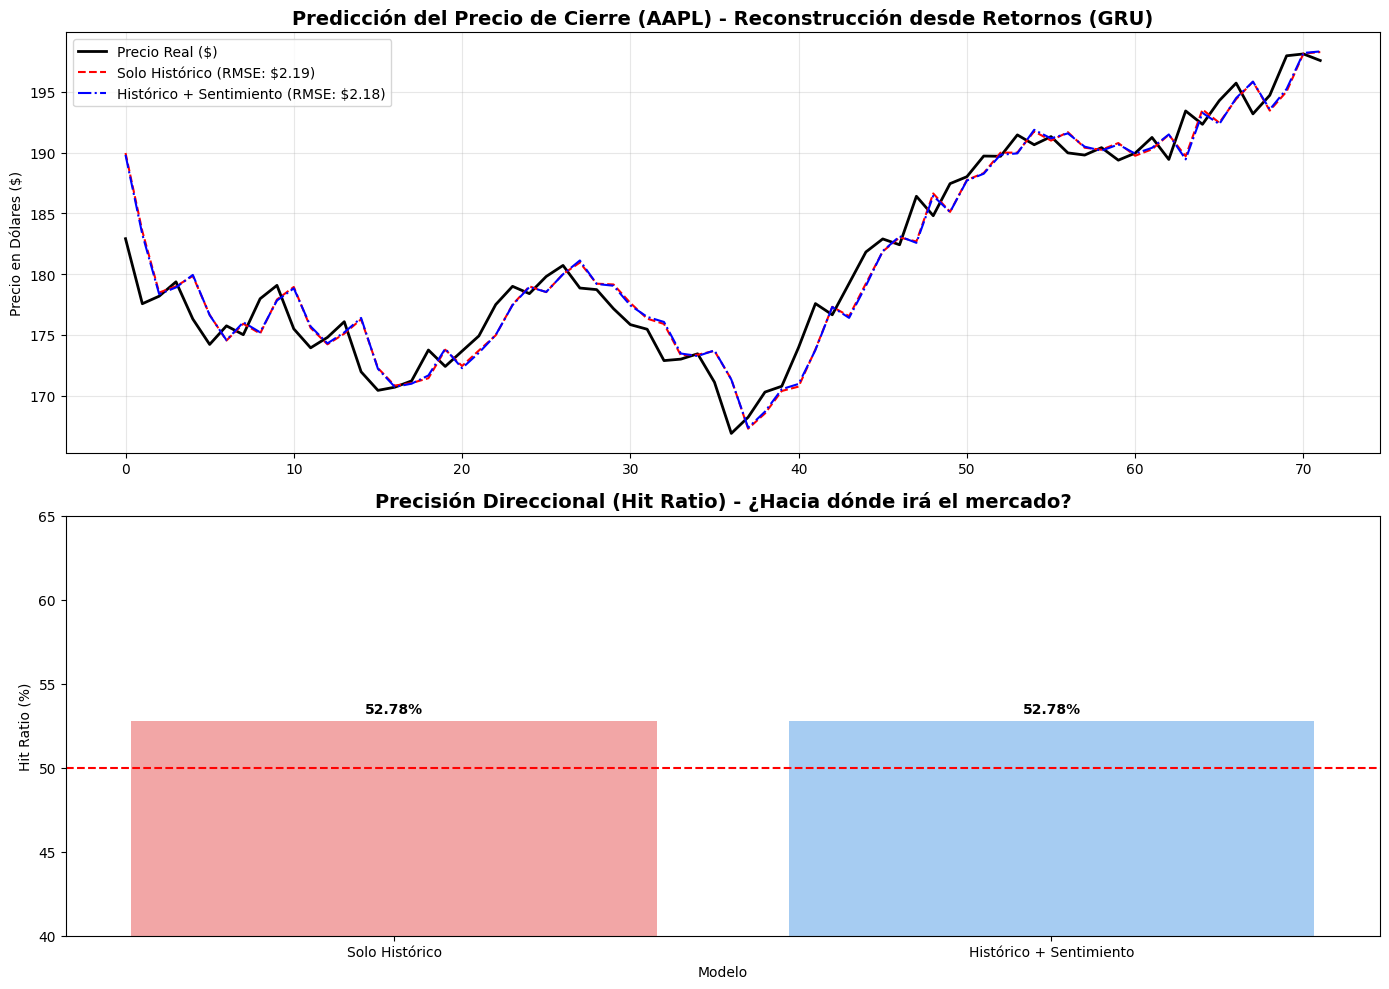

In [ ]:
prueba_retornos_gru("AAPL")

INICIANDO EXPERIMENTO GRU: NVDA


[*********************100%***********************]  1 of 1 completed


Datos alineados para NVDA: 588 días bursátiles.
Entrenando GRU Univariante...
Entrenando GRU Multivariante...



RESULTADOS FINALES NVDA (Arquitectura GRU)
Modelo Solo Histórico -> RMSE: $1.07 | Hit Ratio: 56.25%
Modelo + Sentimiento  -> RMSE: $1.06 | Hit Ratio: 55.36%


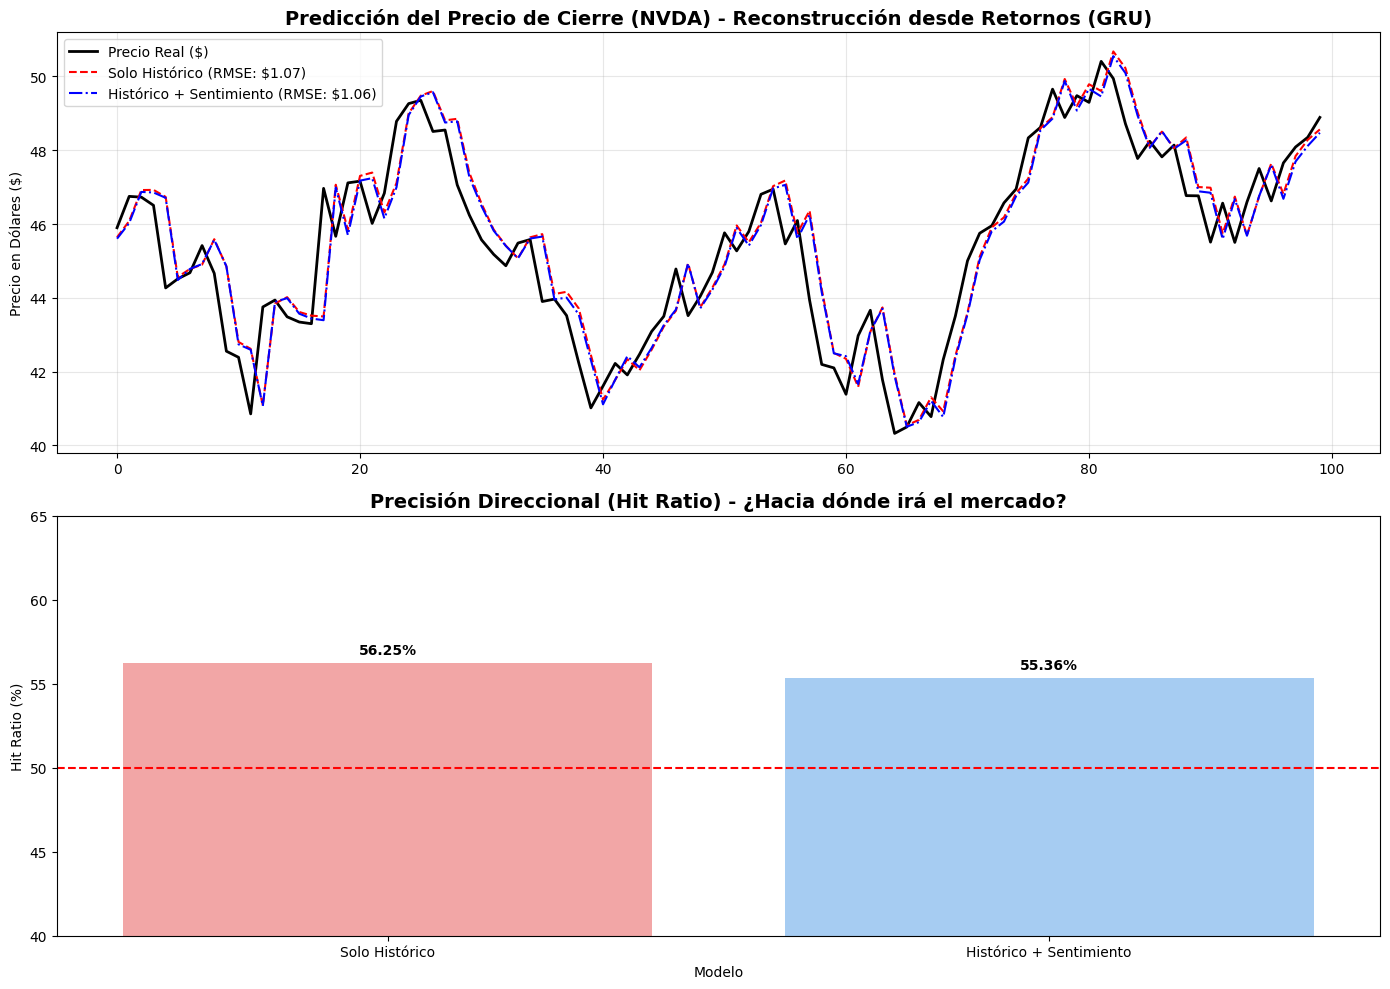

In [ ]:
prueba_retornos_gru("NVDA")

## Experimentación para mitigar la estocastidad de las pruebas.

- Se ejecuta 100 veces el modelo.

In [ ]:
def experimentos_lstm(ticker_elegido, n_runs=100):
    tiempo_inicio = time.time()
    TICKER = ticker_elegido
    RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'
    window_size = 30

    print("="*70)
    print(f"INICIANDO ESTUDIO DE ROBUSTEZ: {n_runs} EJECUCIONES PARA {TICKER}")
    print("="*70)

    # PREPARACIÓN DE DATOS
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()
    df_precios.index = df_precios.index.tz_localize(None)

    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    df_sent = pd.read_parquet(RUTA_SENTIMIENTO)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()

    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))
    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas(data_x, data_y, window):
        X, y = [], []
        for i in range(len(data_x) - window):
            X.append(data_x[i:i + window])
            y.append(data_y[i + window])
        return np.array(X), np.array(y)

    X_uni, y_uni = crear_ventanas(df_merged[['Ret_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)
    X_multi, _ = crear_ventanas(df_merged[['Ret_Scaled', 'Sent_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)

    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]
    y_train, y_test = y_uni[:split], y_uni[split:]

    # BUCLE DE EXPERIMENTOS
    lista_rmse_uni, lista_rmse_multi = [], []
    lista_hr_uni, lista_hr_multi = [], []
    preds_acu_uni_ret, preds_acu_multi_ret = [], []
    preds_acu_uni_usd, preds_acu_multi_usd = [], []

    for i in range(n_runs):
        tf.keras.backend.clear_session()
        np.random.seed(i)
        tf.random.set_seed(i)
        random.seed(i)

        def crear_modelo(input_shape):
            m = Sequential([Input(shape=input_shape), LSTM(50, return_sequences=True), Dropout(0.2),
                            LSTM(50, return_sequences=False), Dropout(0.2), Dense(25), Dense(1)])
            m.compile(optimizer='adam', loss='mse')
            return m

        m_uni = crear_modelo((window_size, 1))
        m_uni.fit(X_train_u, y_train, batch_size=32, epochs=20, verbose=0)

        m_multi = crear_modelo((window_size, 2))
        m_multi.fit(X_train_m, y_train, batch_size=32, epochs=20, verbose=0)

        # Predicciones de Retornos
        p_u_ret = scaler_retorno.inverse_transform(m_uni.predict(X_test_u, verbose=0)).flatten()
        p_m_ret = scaler_retorno.inverse_transform(m_multi.predict(X_test_m, verbose=0)).flatten()
        actual_ret = scaler_retorno.inverse_transform(y_test.reshape(-1, 1)).flatten()

        # Reconstrucción a Precios
        precios_ayer = df_merged['Close'].values[-(len(p_u_ret)+1):-1]
        precio_real = df_merged['Close'].values[-len(p_u_ret):]
        p_u_usd = precios_ayer * np.exp(p_u_ret)
        p_m_usd = precios_ayer * np.exp(p_m_ret)

        preds_acu_uni_ret.append(p_u_ret)
        preds_acu_multi_ret.append(p_m_ret)
        preds_acu_uni_usd.append(p_u_usd)
        preds_acu_multi_usd.append(p_m_usd)

        lista_rmse_uni.append(np.sqrt(mean_squared_error(precio_real, p_u_usd)))
        lista_rmse_multi.append(np.sqrt(mean_squared_error(precio_real, p_m_usd)))
        lista_hr_uni.append(np.mean(np.sign(actual_ret) == np.sign(p_u_ret)) * 100)
        lista_hr_multi.append(np.mean(np.sign(actual_ret) == np.sign(p_m_ret)) * 100)

        if (i + 1) % 10 == 0:
            print(f"   [Progreso] Completadas {i + 1}/{n_runs} ejecuciones...")


    # CÁLCULO DE MEDIAS Y GRÁFICAS
    media_uni_ret = np.mean(preds_acu_uni_ret, axis=0)
    media_multi_ret = np.mean(preds_acu_multi_ret, axis=0)
    media_uni_usd = np.mean(preds_acu_uni_usd, axis=0)
    media_multi_usd = np.mean(preds_acu_multi_usd, axis=0)

    tiempo_total = time.time() - tiempo_inicio
    print(f"\n Experimento completado en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s")

    fig, axes = plt.subplots(3, 1, figsize=(15, 15))
    ultimos_dias = 100

    # PRECIOS RECONSTRUIDOS
    axes[0].plot(precio_real[-ultimos_dias:], label="Precio Real ($)", color='black', linewidth=2)
    axes[0].plot(media_uni_usd[-ultimos_dias:], label=f"Media Univariante (RMSE: ${np.mean(lista_rmse_uni):.2f})", color='red', linestyle='--')
    axes[0].plot(media_multi_usd[-ultimos_dias:], label=f"Media Multivariante (RMSE: ${np.mean(lista_rmse_multi):.2f})", color='blue', linestyle='-.')
    axes[0].set_title(f"Price Forecasting Comparison: {TICKER} (Media de {n_runs} ejecuciones)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Price ($)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # RETORNOS LOGARÍTMICOS
    axes[1].plot(actual_ret[-ultimos_dias:], label="Actual Log Returns", color='gray', alpha=0.5, linewidth=1.5)
    axes[1].plot(media_uni_ret[-ultimos_dias:], label="LSTM Univariante Returns", color='red', alpha=0.8, linestyle='--')
    axes[1].plot(media_multi_ret[-ultimos_dias:], label="LSTM Multivariante Returns", color='blue', alpha=0.8, linestyle='-.')
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--') # Línea de zero (0)
    axes[1].set_title(f"{TICKER} Returns Forecasting: Deep Learning Comparison", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Time Steps (Test Set)")
    axes[1].set_ylabel("Log Returns")
    axes[1].legend()

    # HIT RATIO
    df_bar = pd.DataFrame({
        'Model': ['Solo Histórico', 'Histórico + Sentimiento'],
        'Hit Ratio': [np.mean(lista_hr_uni), np.mean(lista_hr_multi)],
        'STD': [np.std(lista_hr_uni), np.std(lista_hr_multi)]
    })

    sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])
    axes[2].errorbar(x=[0, 1], y=df_bar['Hit Ratio'], yerr=df_bar['STD'], fmt='none', c='black', capsize=5)
    axes[2].axhline(50, color='red', linestyle='--', label="Random Guess (50%)")
    axes[2].set_title("Model Leaderboard: Directional Accuracy (Hit Ratio Medio)", fontsize=14, fontweight='bold')
    axes[2].set_ylim(45, 60)
    axes[2].set_ylabel("Hit Ratio (%)")
    axes[2].legend()

    for i, val in enumerate(df_bar['Hit Ratio']):
        axes[2].text(i, val + 1, f"{val:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

INICIANDO ESTUDIO DE ROBUSTEZ: 100 EJECUCIONES PARA AAPL
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

 Experimento completado en 40m 28s


/tmp/ipykernel_2570/4035415881.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])


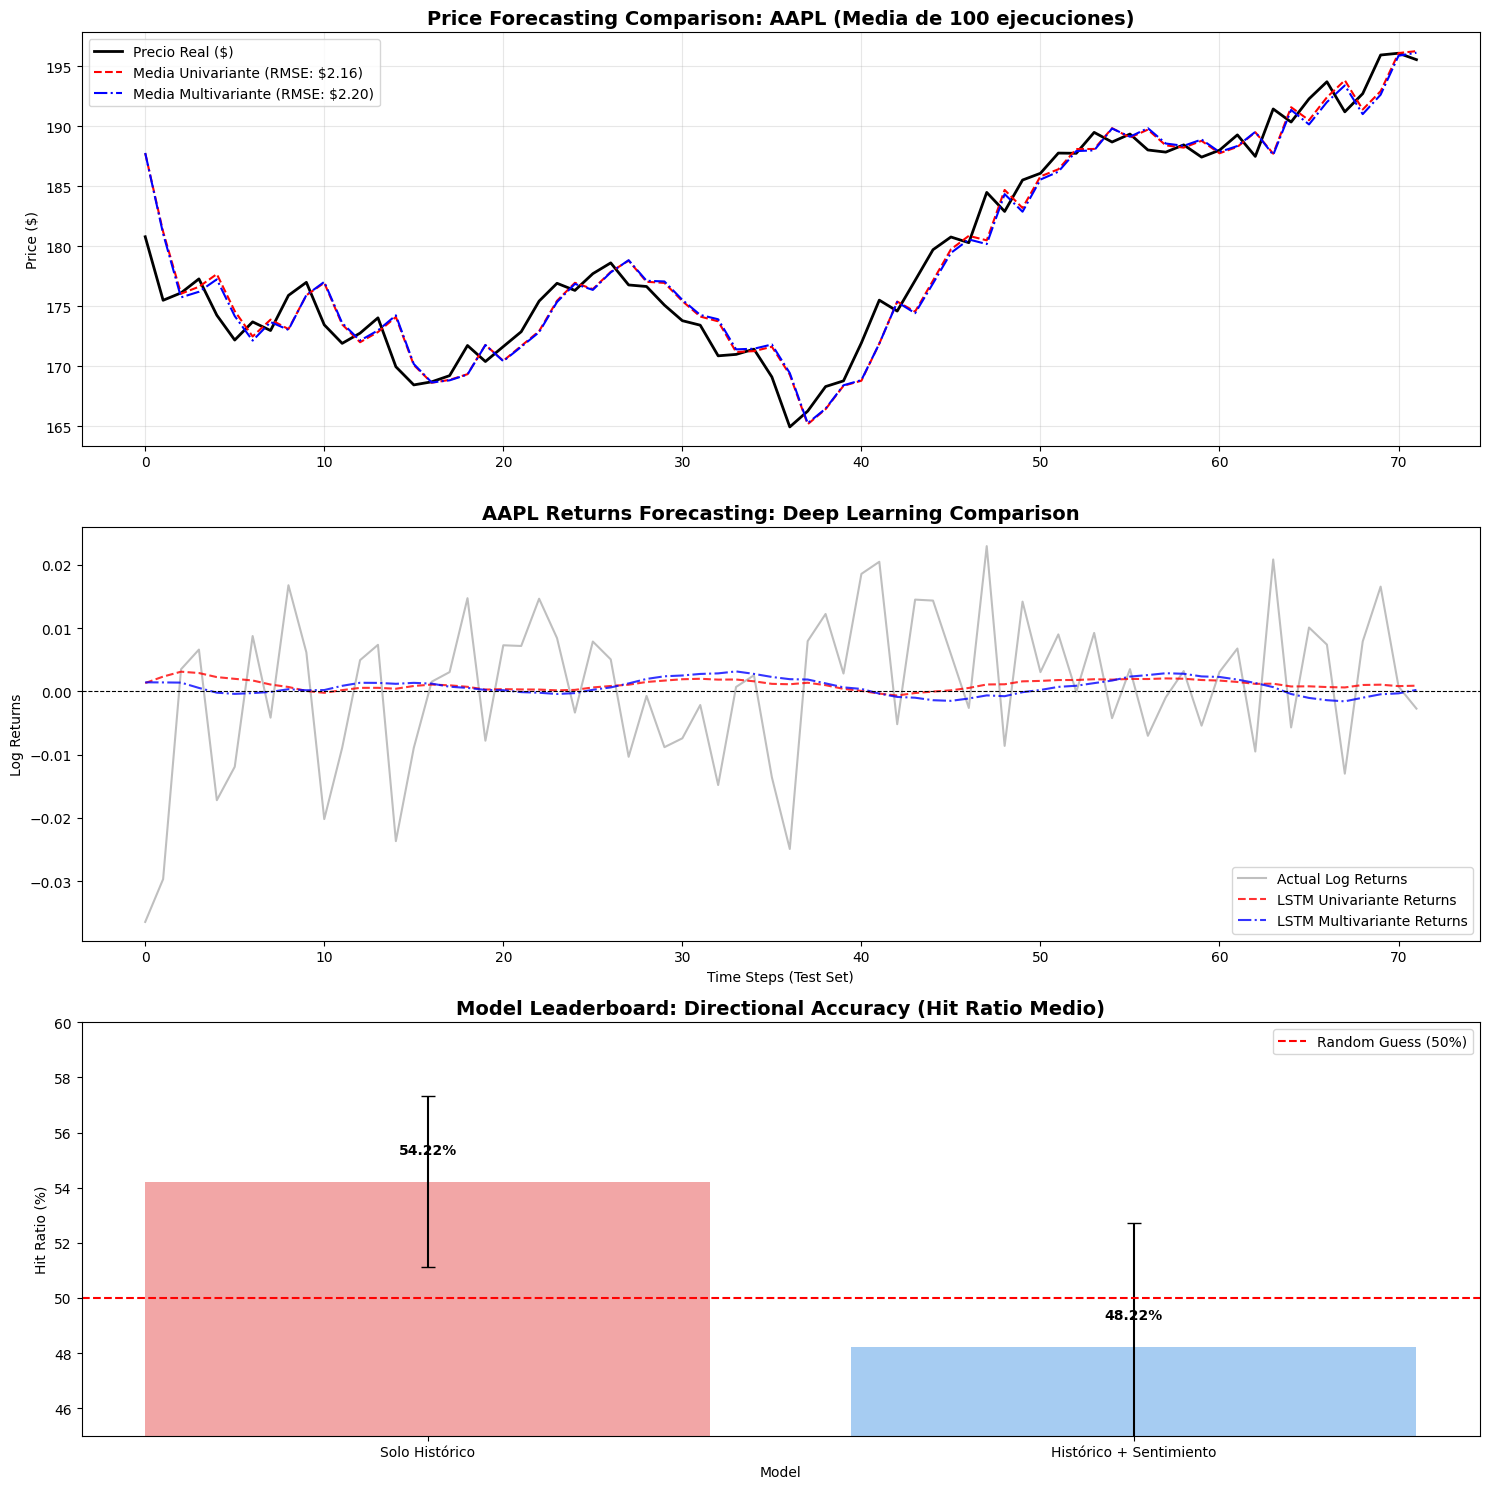

In [ ]:
experimentos_lstm("AAPL", n_runs=100)

- Probamos con Nvidia.

INICIANDO ESTUDIO DE ROBUSTEZ: 100 EJECUCIONES PARA NVDA
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

 Experimento completado en 64m 0s


/tmp/ipykernel_2570/4035415881.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])


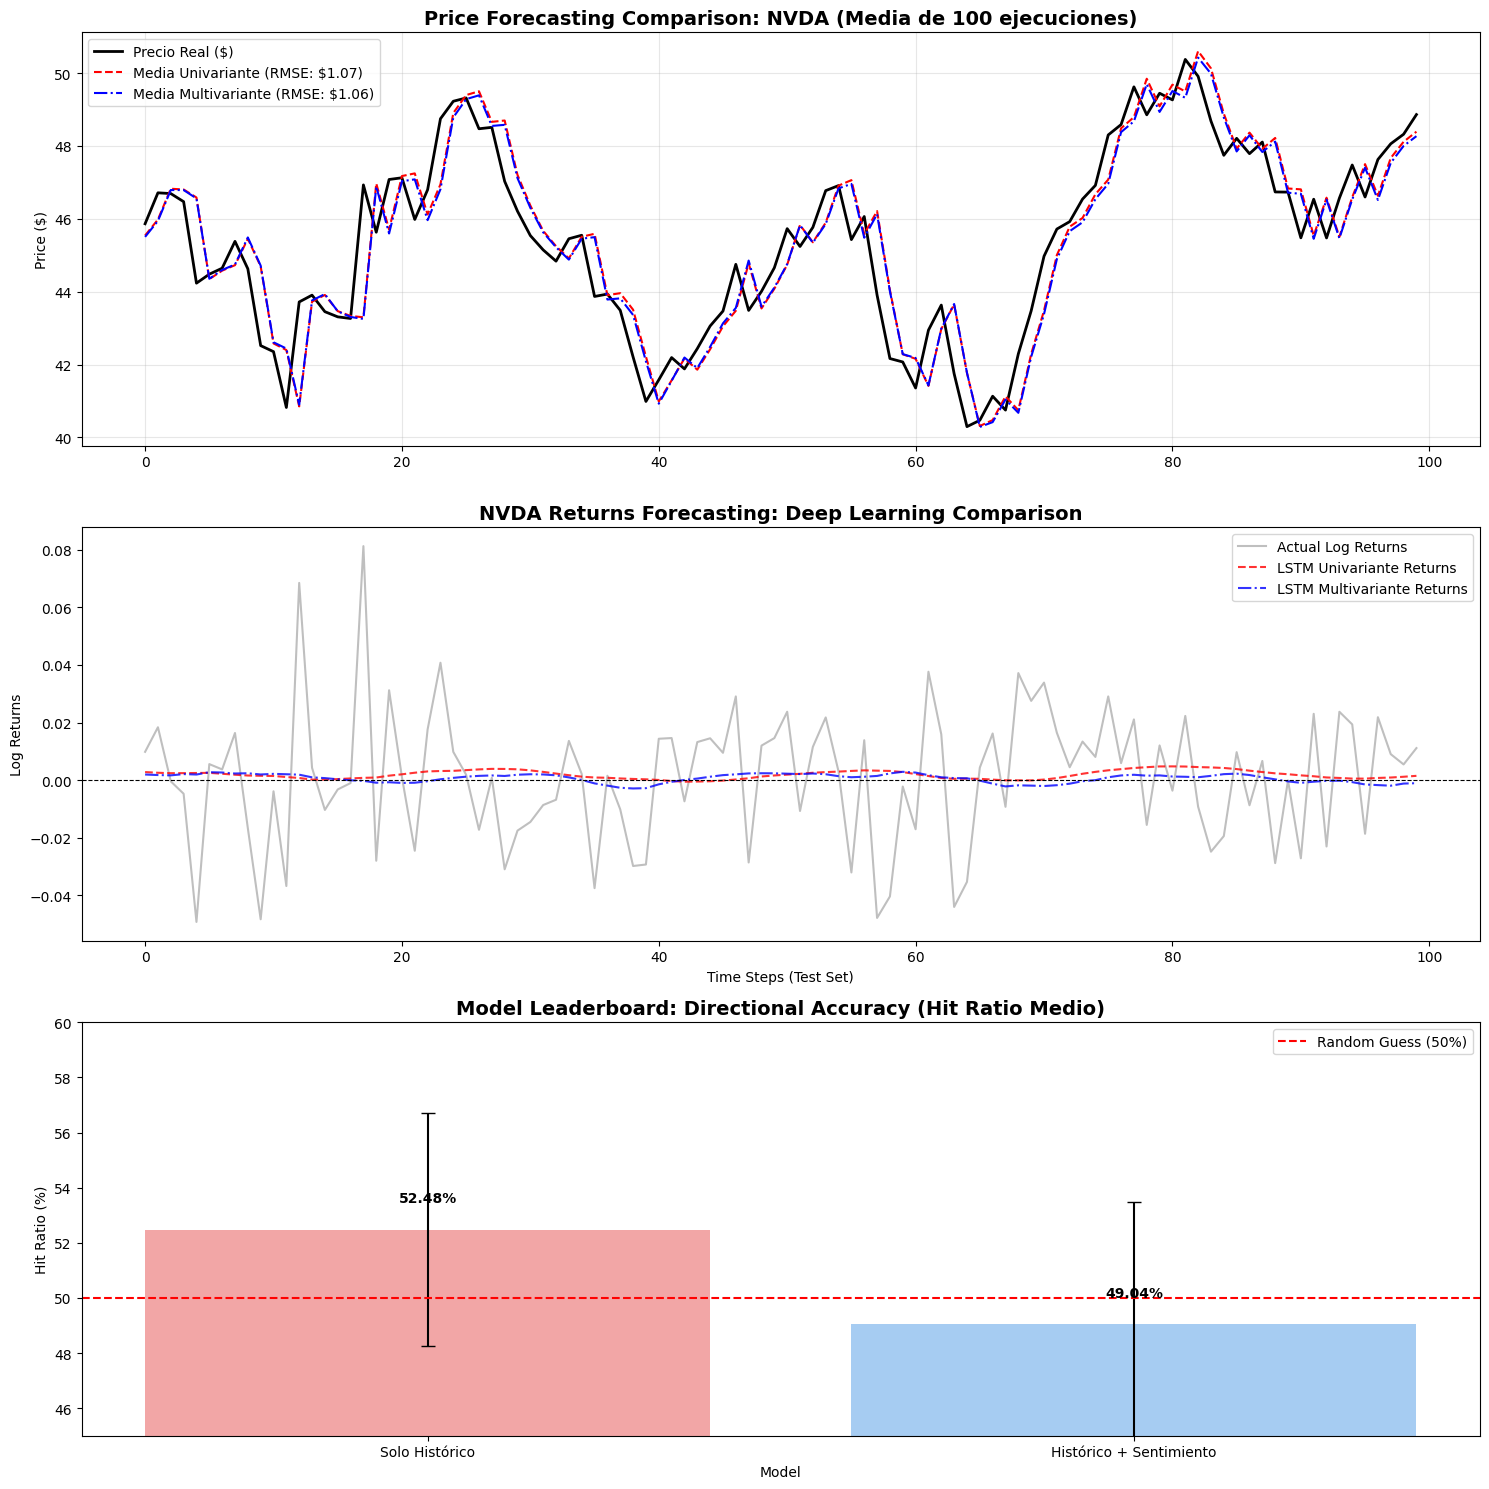

In [ ]:
experimentos_lstm("NVDA", n_runs=100)

- Probamos la experimentación de 100 ejecucciones con GRU.

In [ ]:
def experimentos_gru(ticker_elegido, n_runs=100):
    tiempo_inicio = time.time()
    TICKER = ticker_elegido
    RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'
    window_size = 30

    print("="*70)
    print(f"INICIANDO ESTUDIO DE ROBUSTEZ (GRU): {n_runs} EJECUCIONES PARA {TICKER}")
    print("="*70)

    # PREPARACIÓN DE DATOS
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()
    df_precios.index = df_precios.index.tz_localize(None)

    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    df_sent = pd.read_parquet(RUTA_SENTIMIENTO)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()

    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))
    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas(data_x, data_y, window):
        X, y = [], []
        for i in range(len(data_x) - window):
            X.append(data_x[i:i + window])
            y.append(data_y[i + window])
        return np.array(X), np.array(y)

    X_uni, y_uni = crear_ventanas(df_merged[['Ret_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)
    X_multi, _ = crear_ventanas(df_merged[['Ret_Scaled', 'Sent_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)

    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]
    y_train, y_test = y_uni[:split], y_uni[split:]

    # BUCLE DE EXPERIMENTOS
    lista_rmse_uni, lista_rmse_multi = [], []
    lista_hr_uni, lista_hr_multi = [], []

    preds_acu_uni_ret, preds_acu_multi_ret = [], []
    preds_acu_uni_usd, preds_acu_multi_usd = [], []

    for i in range(n_runs):
        tf.keras.backend.clear_session()
        np.random.seed(i)
        tf.random.set_seed(i)
        random.seed(i)

        # Reemplazamos LSTM por GRU en la arquitectura
        def crear_modelo(input_shape):
            m = Sequential([
                Input(shape=input_shape),
                GRU(50, return_sequences=True), Dropout(0.2),
                GRU(50, return_sequences=False), Dropout(0.2),
                Dense(25), Dense(1)
            ])
            m.compile(optimizer='adam', loss='mse')
            return m

        m_uni = crear_modelo((window_size, 1))
        m_uni.fit(X_train_u, y_train, batch_size=32, epochs=20, verbose=0)

        m_multi = crear_modelo((window_size, 2))
        m_multi.fit(X_train_m, y_train, batch_size=32, epochs=20, verbose=0)

        p_u_ret = scaler_retorno.inverse_transform(m_uni.predict(X_test_u, verbose=0)).flatten()
        p_m_ret = scaler_retorno.inverse_transform(m_multi.predict(X_test_m, verbose=0)).flatten()
        actual_ret = scaler_retorno.inverse_transform(y_test.reshape(-1, 1)).flatten()

        precios_ayer = df_merged['Close'].values[-(len(p_u_ret)+1):-1]
        precio_real = df_merged['Close'].values[-len(p_u_ret):]
        p_u_usd = precios_ayer * np.exp(p_u_ret)
        p_m_usd = precios_ayer * np.exp(p_m_ret)

        preds_acu_uni_ret.append(p_u_ret)
        preds_acu_multi_ret.append(p_m_ret)
        preds_acu_uni_usd.append(p_u_usd)
        preds_acu_multi_usd.append(p_m_usd)

        lista_rmse_uni.append(np.sqrt(mean_squared_error(precio_real, p_u_usd)))
        lista_rmse_multi.append(np.sqrt(mean_squared_error(precio_real, p_m_usd)))
        lista_hr_uni.append(np.mean(np.sign(actual_ret) == np.sign(p_u_ret)) * 100)
        lista_hr_multi.append(np.mean(np.sign(actual_ret) == np.sign(p_m_ret)) * 100)

        if (i + 1) % 10 == 0:
            print(f"   [Progreso] Completadas {i + 1}/{n_runs} ejecuciones...")

    # CÁLCULO DE MEDIAS Y GRÁFICAS
    media_uni_ret = np.mean(preds_acu_uni_ret, axis=0)
    media_multi_ret = np.mean(preds_acu_multi_ret, axis=0)
    media_uni_usd = np.mean(preds_acu_uni_usd, axis=0)
    media_multi_usd = np.mean(preds_acu_multi_usd, axis=0)

    tiempo_total = time.time() - tiempo_inicio
    print(f"\nExperimento GRU completado en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s")

    fig, axes = plt.subplots(3, 1, figsize=(15, 15))
    ultimos_dias = 100

    # PRECIOS
    axes[0].plot(precio_real[-ultimos_dias:], label="Precio Real ($)", color='black', linewidth=2)
    axes[0].plot(media_uni_usd[-ultimos_dias:], label=f"Media GRU Univariante (RMSE: ${np.mean(lista_rmse_uni):.2f})", color='red', linestyle='--')
    axes[0].plot(media_multi_usd[-ultimos_dias:], label=f"Media GRU Multivariante (RMSE: ${np.mean(lista_rmse_multi):.2f})", color='blue', linestyle='-.')
    axes[0].set_title(f"Price Forecasting Comparison: {TICKER} (Media de {n_runs} ejecuciones - GRU)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Price ($)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # RETORNOS
    axes[1].plot(actual_ret[-ultimos_dias:], label="Actual Log Returns", color='gray', alpha=0.5, linewidth=1.5)
    axes[1].plot(media_uni_ret[-ultimos_dias:], label="GRU Univariante Returns", color='red', alpha=0.8, linestyle='--') # <-- CAMBIO 3: Actualizadas las leyendas
    axes[1].plot(media_multi_ret[-ultimos_dias:], label="GRU Multivariante Returns", color='blue', alpha=0.8, linestyle='-.')
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"{TICKER} Returns Forecasting: Deep Learning Comparison (GRU)", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Time Steps (Test Set)")
    axes[1].set_ylabel("Log Returns")
    axes[1].legend()

    # HIT RATIO
    df_bar = pd.DataFrame({
        'Model': ['Solo Histórico', 'Histórico + Sentimiento'],
        'Hit Ratio': [np.mean(lista_hr_uni), np.mean(lista_hr_multi)],
        'STD': [np.std(lista_hr_uni), np.std(lista_hr_multi)]
    })

    sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])
    axes[2].errorbar(x=[0, 1], y=df_bar['Hit Ratio'], yerr=df_bar['STD'], fmt='none', c='black', capsize=5)
    axes[2].axhline(50, color='red', linestyle='--', label="Random Guess (50%)")
    axes[2].set_title("Model Leaderboard: Directional Accuracy (Hit Ratio Medio - GRU)", fontsize=14, fontweight='bold')
    axes[2].set_ylim(45, 60)
    axes[2].set_ylabel("Hit Ratio (%)")
    axes[2].legend()

    for i, val in enumerate(df_bar['Hit Ratio']):
        axes[2].text(i, val + 1, f"{val:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


INICIANDO ESTUDIO DE ROBUSTEZ (GRU): 100 EJECUCIONES PARA AAPL


   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

✨ Experimento GRU completado en 33m 8s


/tmp/ipykernel_2079/2257665350.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])


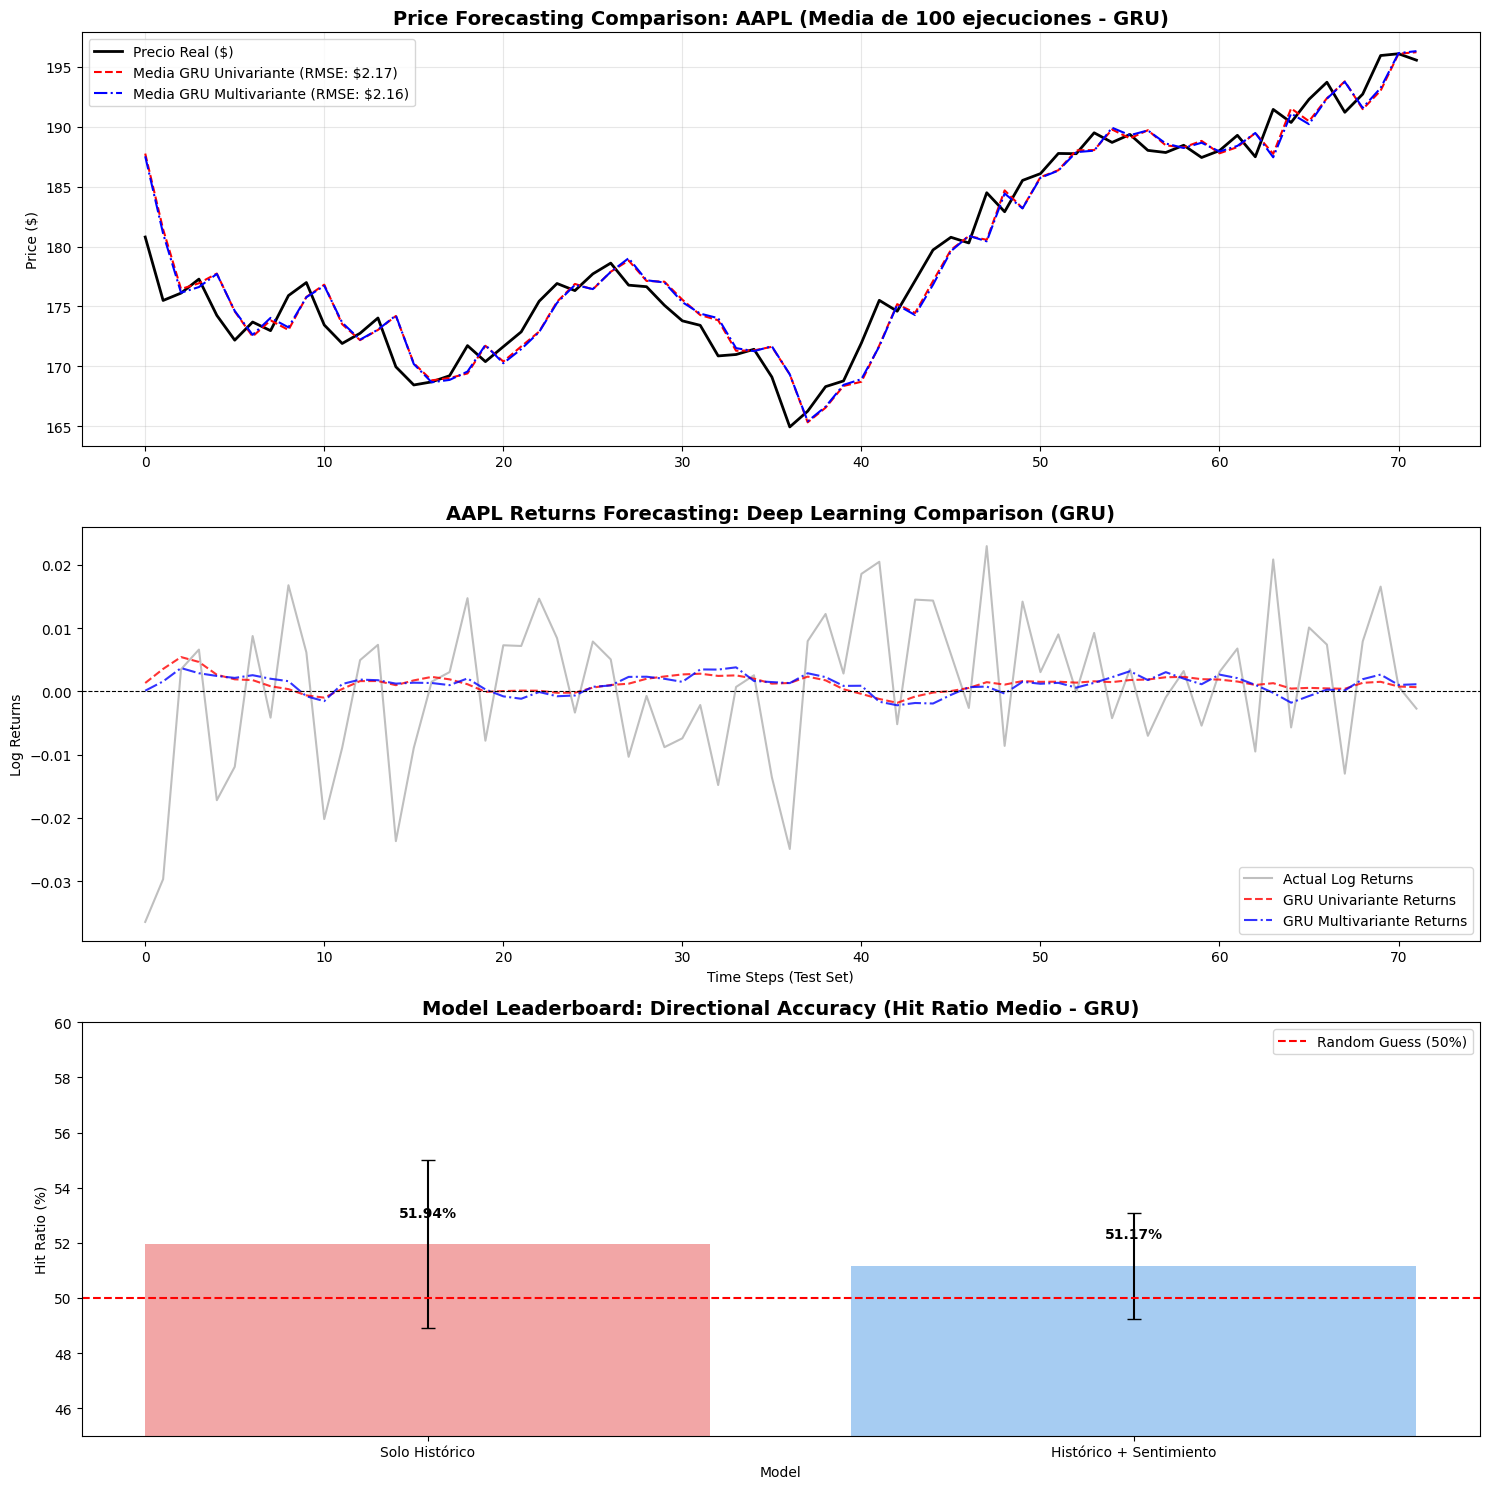

In [ ]:
experimentos_gru("AAPL", n_runs=100)

INICIANDO ESTUDIO DE ROBUSTEZ (GRU): 100 EJECUCIONES PARA NVDA


   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento GRU completado en 48m 59s


/tmp/ipykernel_88219/102082917.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])


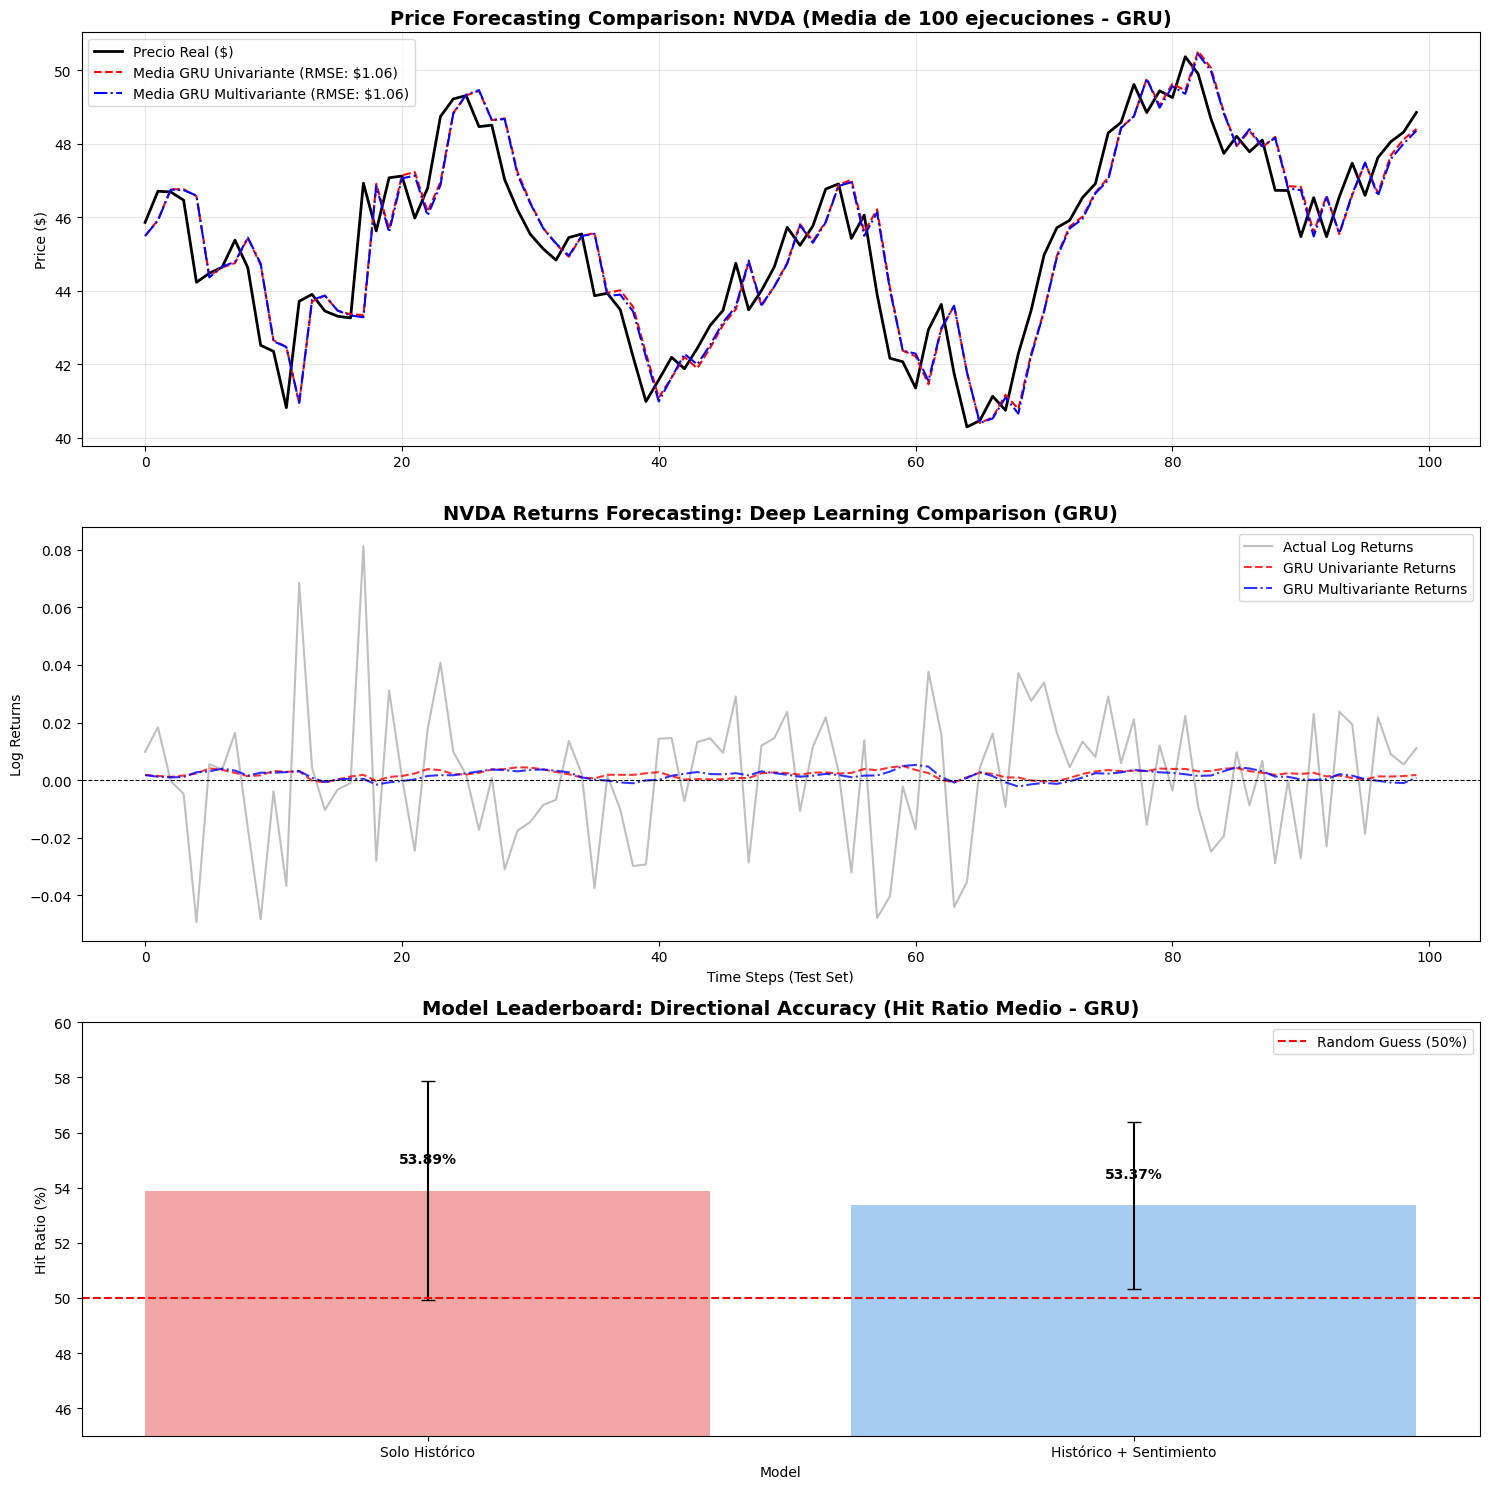

In [ ]:
experimentos_gru("NVDA", n_runs=100)

## Medidas para mitigar el lagging
Como se observa en los anteriores resultados, ambos modelos sufren un retraso llamado lagging. Por ello se decide realizar una serie de cambios para elimianr este fenómeno.

- Búsqueda de la ventana optima.


In [ ]:
def evaluar_ventanas_lstm(ticker_elegido, ventanas=[5, 10, 15, 30], n_runs=10):

    tiempo_inicio = time.time()
    TICKER = ticker_elegido
    RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    print("="*70)
    print(f"INICIANDO ESTUDIO DE VENTANAS TEMPORALES PARA {TICKER}")
    print(f"Ventanas a evaluar: {ventanas} días | Ejecuciones por ventana: {n_runs}")
    print("="*70)

    # PREPARACIÓN DE DATOS
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()
    df_precios.index = df_precios.index.tz_localize(None)

    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    df_sent = pd.read_parquet(RUTA_SENTIMIENTO)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()

    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))
    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas(data_x, data_y, window):
        X, y = [], []
        for i in range(len(data_x) - window):
            X.append(data_x[i:i + window])
            y.append(data_y[i + window])
        return np.array(X), np.array(y)

    resultados_evaluacion = []

    # BUCLE PRINCIPAL SOBRE LAS VENTANAS
    for window_size in ventanas:
        print(f"\nEvaluando ventana de {window_size} días...")
        X_uni, y_uni = crear_ventanas(df_merged[['Ret_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)
        X_multi, _ = crear_ventanas(df_merged[['Ret_Scaled', 'Sent_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)

        split = int(len(X_uni) * 0.8)
        X_train_u, X_test_u = X_uni[:split], X_uni[split:]
        X_train_m, X_test_m = X_multi[:split], X_multi[split:]
        y_train, y_test = y_uni[:split], y_uni[split:]

        lista_hr_uni, lista_hr_multi = [], []
        lista_rmse_uni, lista_rmse_multi = [], []

        for i in range(n_runs):
            tf.keras.backend.clear_session()
            np.random.seed(i)
            tf.random.set_seed(i)
            random.seed(i)

            def crear_modelo(input_shape):
                m = Sequential([
                    Input(shape=input_shape),
                    LSTM(50, return_sequences=True), Dropout(0.2),
                    LSTM(50, return_sequences=False), Dropout(0.2),
                    Dense(25), Dense(1)
                ])
                m.compile(optimizer='adam', loss='mse')
                return m

            m_uni = crear_modelo((window_size, 1))
            m_uni.fit(X_train_u, y_train, batch_size=32, epochs=20, verbose=0)

            m_multi = crear_modelo((window_size, 2))
            m_multi.fit(X_train_m, y_train, batch_size=32, epochs=20, verbose=0)

            # Predicciones de Retornos
            p_u_ret = scaler_retorno.inverse_transform(m_uni.predict(X_test_u, verbose=0)).flatten()
            p_m_ret = scaler_retorno.inverse_transform(m_multi.predict(X_test_m, verbose=0)).flatten()
            actual_ret = scaler_retorno.inverse_transform(y_test.reshape(-1, 1)).flatten()

            # Reconstrucción a Precios
            precios_ayer = df_merged['Close'].values[-(len(p_u_ret)+1):-1]
            precio_real = df_merged['Close'].values[-len(p_u_ret):]
            p_u_usd = precios_ayer * np.exp(p_u_ret)
            p_m_usd = precios_ayer * np.exp(p_m_ret)

            # Métricas
            lista_hr_uni.append(np.mean(np.sign(actual_ret) == np.sign(p_u_ret)) * 100)
            lista_hr_multi.append(np.mean(np.sign(actual_ret) == np.sign(p_m_ret)) * 100)
            lista_rmse_uni.append(np.sqrt(mean_squared_error(precio_real, p_u_usd)))
            lista_rmse_multi.append(np.sqrt(mean_squared_error(precio_real, p_m_usd)))

        resultados_evaluacion.append({
            'Ventana': window_size,
            'HR_Uni_Mean': np.mean(lista_hr_uni),
            'HR_Multi_Mean': np.mean(lista_hr_multi),
            'RMSE_Uni_Mean': np.mean(lista_rmse_uni),
            'RMSE_Multi_Mean': np.mean(lista_rmse_multi)
        })
        print(f"Completado. HR Multi Medio: {np.mean(lista_hr_multi):.2f}%")

    # VISUALIZACIÓN COMPARATIVA
    df_res = pd.DataFrame(resultados_evaluacion)

    df_plot_hr = pd.melt(df_res, id_vars=['Ventana'], value_vars=['HR_Uni_Mean', 'HR_Multi_Mean'],
                         var_name='Modelo', value_name='Hit Ratio Medio (%)')
    df_plot_hr['Modelo'] = df_plot_hr['Modelo'].replace({'HR_Uni_Mean': 'Solo Histórico', 'HR_Multi_Mean': 'Histórico + Sentimiento'})

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfica de Hit Ratio
    sns.barplot(data=df_plot_hr, x='Ventana', y='Hit Ratio Medio (%)', hue='Modelo', ax=axes[0], palette=['#ff9999', '#99ccff'])
    axes[0].axhline(50, color='red', linestyle='--', label="Aleatorio (50%)")
    axes[0].set_title(f"Impacto del Tamaño de Ventana en Hit Ratio ({TICKER})", fontweight='bold')
    axes[0].set_ylim(45, max(df_plot_hr['Hit Ratio Medio (%)']) + 2)

    # Gráfica de RMSE
    df_plot_rmse = pd.melt(df_res, id_vars=['Ventana'], value_vars=['RMSE_Uni_Mean', 'RMSE_Multi_Mean'],
                           var_name='Modelo', value_name='RMSE Medio ($)')
    df_plot_rmse['Modelo'] = df_plot_rmse['Modelo'].replace({'RMSE_Uni_Mean': 'Solo Histórico', 'RMSE_Multi_Mean': 'Histórico + Sentimiento'})

    sns.lineplot(data=df_plot_rmse, x='Ventana', y='RMSE Medio ($)', hue='Modelo', marker='o', ax=axes[1], palette=['red', 'blue'])
    axes[1].set_title(f"Impacto del Tamaño de Ventana en RMSE ({TICKER})", fontweight='bold')
    axes[1].set_xticks(ventanas)

    plt.tight_layout()
    plt.show()

    return df_res

INICIANDO ESTUDIO DE VENTANAS TEMPORALES PARA AAPL
Ventanas a evaluar: [5, 10, 15, 30] días | Ejecuciones por ventana: 10

Evaluando ventana de 5 días...


Completado. HR Multi Medio: 56.62%

Evaluando ventana de 10 días...
Completado. HR Multi Medio: 57.11%

Evaluando ventana de 15 días...
Completado. HR Multi Medio: 46.53%

Evaluando ventana de 30 días...
Completado. HR Multi Medio: 45.69%


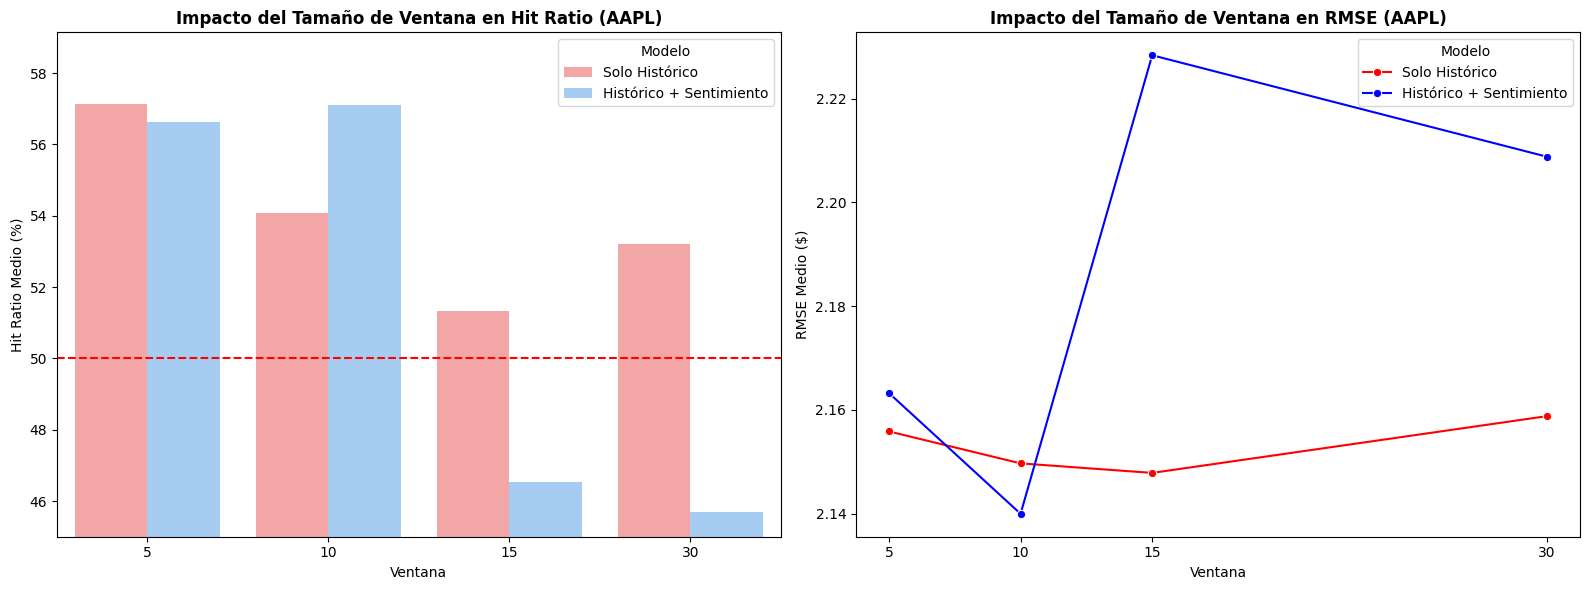

,Ventana,HR_Uni_Mean,HR_Multi_Mean,RMSE_Uni_Mean,RMSE_Multi_Mean
0,5,57.142857,56.623377,2.155854,2.163250
1,10,54.078947,57.105263,2.149694,2.139974
2,15,51.333333,46.533333,2.147856,2.228358
3,30,53.194444,45.694444,2.158800,2.208793


In [ ]:
evaluar_ventanas_lstm("AAPL", ventanas=[5, 10, 15, 30], n_runs=10)

 Se ejeucta el sistema 100 veces con la ventana óptima obtenida de la prueba anterior.

In [ ]:
def experimentos_lstm_optimo(ticker_elegido, n_runs=100):
    tiempo_inicio = time.time()
    TICKER = ticker_elegido
    RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    window_size = 10

    print("="*70)
    print(f"INICIANDO ESTUDIO DE ROBUSTEZ: {n_runs} EJECUCIONES PARA {TICKER}")
    print(f"Configuración Óptima: Ventana de {window_size} días")
    print("="*70)

    # PREPARACIÓN DE DATOS
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()
    df_precios.index = df_precios.index.tz_localize(None)

    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    df_sent = pd.read_parquet(RUTA_SENTIMIENTO)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()

    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))
    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas(data_x, data_y, window):
        X, y = [], []
        for i in range(len(data_x) - window):
            X.append(data_x[i:i + window])
            y.append(data_y[i + window])
        return np.array(X), np.array(y)

    X_uni, y_uni = crear_ventanas(df_merged[['Ret_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)
    X_multi, _ = crear_ventanas(df_merged[['Ret_Scaled', 'Sent_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)

    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]
    y_train, y_test = y_uni[:split], y_uni[split:]

    # BUCLE DE EXPERIMENTOS
    lista_rmse_uni, lista_rmse_multi = [], []
    lista_hr_uni, lista_hr_multi = [], []
    preds_acu_uni_ret, preds_acu_multi_ret = [], []
    preds_acu_uni_usd, preds_acu_multi_usd = [], []

    for i in range(n_runs):
        tf.keras.backend.clear_session()
        np.random.seed(i)
        tf.random.set_seed(i)
        random.seed(i)

        def crear_modelo(input_shape):
            m = Sequential([Input(shape=input_shape), LSTM(50, return_sequences=True), Dropout(0.2),
                            LSTM(50, return_sequences=False), Dropout(0.2), Dense(25), Dense(1)])
            m.compile(optimizer='adam', loss='mse')
            return m

        m_uni = crear_modelo((window_size, 1))
        m_uni.fit(X_train_u, y_train, batch_size=32, epochs=20, verbose=0)

        m_multi = crear_modelo((window_size, 2))
        m_multi.fit(X_train_m, y_train, batch_size=32, epochs=20, verbose=0)

        # Predicciones de Retornos
        p_u_ret = scaler_retorno.inverse_transform(m_uni.predict(X_test_u, verbose=0)).flatten()
        p_m_ret = scaler_retorno.inverse_transform(m_multi.predict(X_test_m, verbose=0)).flatten()
        actual_ret = scaler_retorno.inverse_transform(y_test.reshape(-1, 1)).flatten()

        # Reconstrucción a Precios
        precios_ayer = df_merged['Close'].values[-(len(p_u_ret)+1):-1]
        precio_real = df_merged['Close'].values[-len(p_u_ret):]
        p_u_usd = precios_ayer * np.exp(p_u_ret)
        p_m_usd = precios_ayer * np.exp(p_m_ret)

        preds_acu_uni_ret.append(p_u_ret)
        preds_acu_multi_ret.append(p_m_ret)
        preds_acu_uni_usd.append(p_u_usd)
        preds_acu_multi_usd.append(p_m_usd)

        lista_rmse_uni.append(np.sqrt(mean_squared_error(precio_real, p_u_usd)))
        lista_rmse_multi.append(np.sqrt(mean_squared_error(precio_real, p_m_usd)))
        lista_hr_uni.append(np.mean(np.sign(actual_ret) == np.sign(p_u_ret)) * 100)
        lista_hr_multi.append(np.mean(np.sign(actual_ret) == np.sign(p_m_ret)) * 100)

        if (i + 1) % 10 == 0:
            print(f"   [Progreso] Completadas {i + 1}/{n_runs} ejecuciones...")

    # CÁLCULO DE MEDIAS Y GRÁFICAS
    media_uni_ret = np.mean(preds_acu_uni_ret, axis=0)
    media_multi_ret = np.mean(preds_acu_multi_ret, axis=0)
    media_uni_usd = np.mean(preds_acu_uni_usd, axis=0)
    media_multi_usd = np.mean(preds_acu_multi_usd, axis=0)

    tiempo_total = time.time() - tiempo_inicio
    print(f"\nExperimento completado en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s")

    fig, axes = plt.subplots(3, 1, figsize=(15, 15))
    ultimos_dias = 100

    axes[0].plot(precio_real[-ultimos_dias:], label="Precio Real ($)", color='black', linewidth=2)
    axes[0].plot(media_uni_usd[-ultimos_dias:], label=f"Media Univariante (RMSE: ${np.mean(lista_rmse_uni):.2f})", color='red', linestyle='--')
    axes[0].plot(media_multi_usd[-ultimos_dias:], label=f"Media Multivariante (RMSE: ${np.mean(lista_rmse_multi):.2f})", color='blue', linestyle='-.')
    axes[0].set_title(f"Price Forecasting Comparison: {TICKER} (Media de {n_runs} ejecuciones | Ventana: {window_size} días)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Price ($)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(actual_ret[-ultimos_dias:], label="Actual Log Returns", color='gray', alpha=0.5, linewidth=1.5)
    axes[1].plot(media_uni_ret[-ultimos_dias:], label="LSTM Univariante Returns", color='red', alpha=0.8, linestyle='--')
    axes[1].plot(media_multi_ret[-ultimos_dias:], label="LSTM Multivariante Returns", color='blue', alpha=0.8, linestyle='-.')
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"{TICKER} Returns Forecasting: Deep Learning Comparison", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Time Steps (Test Set)")
    axes[1].set_ylabel("Log Returns")
    axes[1].legend()

    df_bar = pd.DataFrame({
        'Model': ['Solo Histórico', 'Histórico + Sentimiento'],
        'Hit Ratio': [np.mean(lista_hr_uni), np.mean(lista_hr_multi)],
        'STD': [np.std(lista_hr_uni), np.std(lista_hr_multi)]
    })

    sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])
    axes[2].errorbar(x=[0, 1], y=df_bar['Hit Ratio'], yerr=df_bar['STD'], fmt='none', c='black', capsize=5)
    axes[2].axhline(50, color='red', linestyle='--', label="Random Guess (50%)")
    axes[2].set_title(f"Model Leaderboard: Directional Accuracy (Hit Ratio Medio sobre {n_runs} iteraciones)", fontsize=14, fontweight='bold')
    axes[2].set_ylim(45, 60)
    axes[2].set_ylabel("Hit Ratio (%)")
    axes[2].legend()

    for i, val in enumerate(df_bar['Hit Ratio']):
        axes[2].text(i, val + 1, f"{val:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

INICIANDO ESTUDIO DE ROBUSTEZ: 100 EJECUCIONES PARA AAPL
Configuración Óptima: Ventana de 10 días
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 36m 14s


/tmp/ipykernel_5307/1710571977.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])


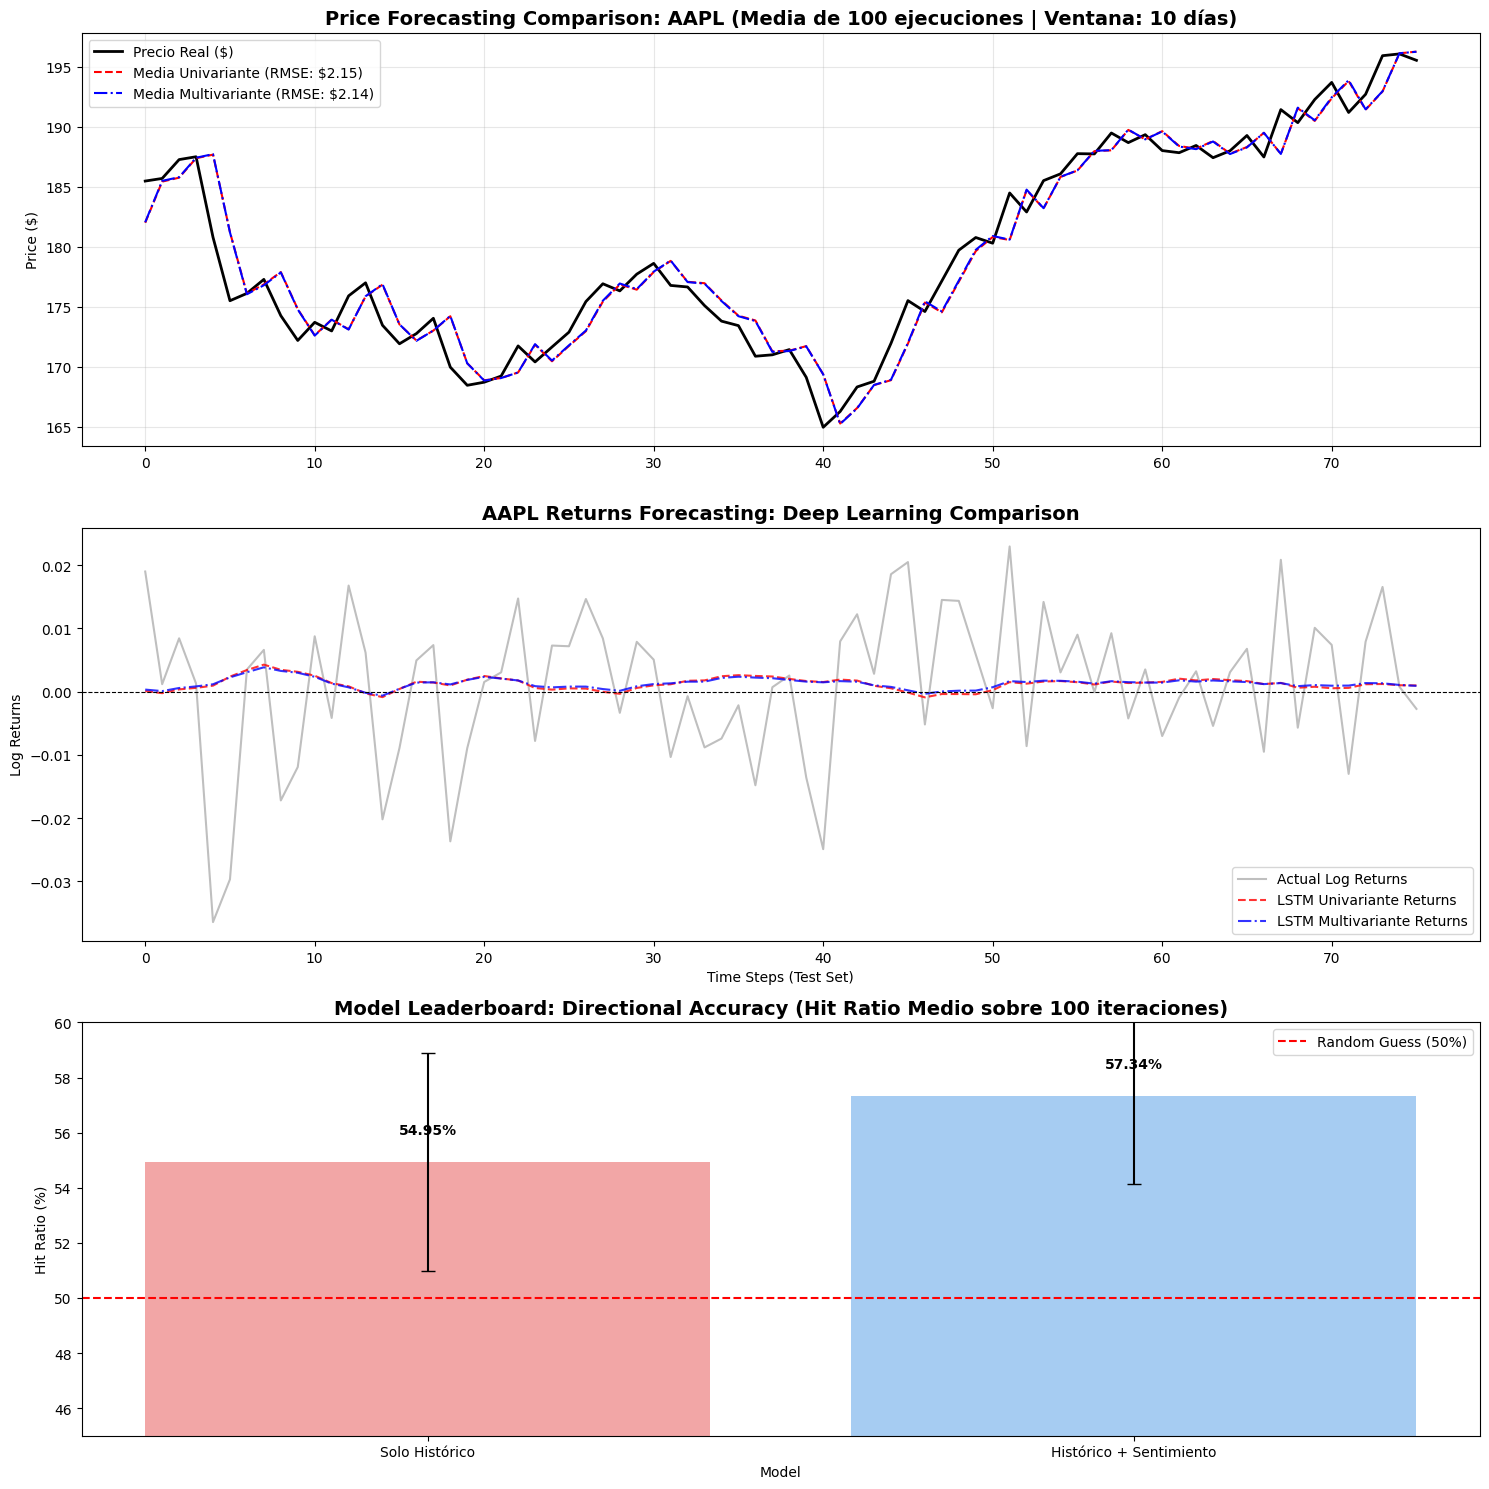

In [ ]:
experimentos_lstm_optimo("AAPL", n_runs=100)

Los resultados mejoran pero el lagging se sigue estando presente, tal y como se observa en la gráfica.

-  Predecimos a 3 días vista


In [ ]:
def experimento_lstm_lookahead(ticker_elegido, n_runs=100, window_size=10, lookahead=3):
    tiempo_inicio = time.time()
    TICKER = ticker_elegido
    RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    print("="*75)
    print(f"INICIANDO ESTUDIO DE ROBUSTEZ: {n_runs} EJECUCIONES PARA {TICKER}")
    print(f"Configuración: Ventana = {window_size} días | Predicción a = {lookahead} DÍAS VISTA")
    print("="*75)

    # PREPARACIÓN DE DATOS
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()
    df_precios.index = df_precios.index.tz_localize(None)

    df_precios['Log_Ret_Diario'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))

    df_precios['Target_Ret'] = np.log(df_precios['Close'].shift(-lookahead) / df_precios['Close'])

    df_sent = pd.read_parquet(RUTA_SENTIMIENTO)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()

    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))
    scaler_target = MinMaxScaler(feature_range=(-1, 1))

    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret_Diario']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])
    df_merged['Target_Scaled'] = scaler_target.fit_transform(df_merged[['Target_Ret']])

    def crear_ventanas_multi_step(df, window):
        X_r, X_s, y, p_base = [], [], [], []
        r_vals = df['Ret_Scaled'].values
        s_vals = df['Sent_Scaled'].values
        t_vals = df['Target_Scaled'].values
        c_vals = df['Close'].values

        for i in range(len(df) - window + 1):
            X_r.append(r_vals[i : i + window])
            X_s.append(s_vals[i : i + window])
            y.append(t_vals[i + window - 1])
            p_base.append(c_vals[i + window - 1])

        return np.array(X_r), np.array(X_s), np.array(y), np.array(p_base)

    X_ret, X_sent, y_targets, p_base_vals = crear_ventanas_multi_step(df_merged, window_size)

    X_uni = np.expand_dims(X_ret, axis=-1)
    X_multi = np.stack((X_ret, X_sent), axis=-1)

    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]
    y_train, y_test = y_targets[:split], y_targets[split:]
    p_base_test = p_base_vals[split:]

    # BUCLE DE EXPERIMENTOS
    lista_rmse_uni, lista_rmse_multi = [], []
    lista_hr_uni, lista_hr_multi = [], []

    preds_acu_uni_ret, preds_acu_multi_ret = [], []
    preds_acu_uni_usd, preds_acu_multi_usd = [], []

    for i in range(n_runs):
        tf.keras.backend.clear_session()
        np.random.seed(i)
        tf.random.set_seed(i)
        random.seed(i)

        def crear_modelo(input_shape):
            m = Sequential([
                Input(shape=input_shape),
                LSTM(50, return_sequences=True), Dropout(0.2),
                LSTM(50, return_sequences=False), Dropout(0.2),
                Dense(25), Dense(1)
            ])
            m.compile(optimizer='adam', loss='mse')
            return m

        m_uni = crear_modelo((window_size, 1))
        m_uni.fit(X_train_u, y_train, batch_size=32, epochs=20, verbose=0)

        m_multi = crear_modelo((window_size, 2))
        m_multi.fit(X_train_m, y_train, batch_size=32, epochs=20, verbose=0)

        # Predicciones (Aún están escaladas)
        p_u_target_scaled = m_uni.predict(X_test_u, verbose=0).flatten()
        p_m_target_scaled = m_multi.predict(X_test_m, verbose=0).flatten()

        # Desescalar para obtener el retorno acumulado a K días real
        p_u_ret_k = scaler_target.inverse_transform(p_u_target_scaled.reshape(-1, 1)).flatten()
        p_m_ret_k = scaler_target.inverse_transform(p_m_target_scaled.reshape(-1, 1)).flatten()
        actual_ret_k = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()

        # Reconstruir a Precios a K días vista
        p_u_usd = p_base_test * np.exp(p_u_ret_k)
        p_m_usd = p_base_test * np.exp(p_m_ret_k)
        precio_real_futuro = p_base_test * np.exp(actual_ret_k)

        preds_acu_uni_ret.append(p_u_ret_k)
        preds_acu_multi_ret.append(p_m_ret_k)
        preds_acu_uni_usd.append(p_u_usd)
        preds_acu_multi_usd.append(p_m_usd)

        # Métricas
        lista_rmse_uni.append(np.sqrt(mean_squared_error(precio_real_futuro, p_u_usd)))
        lista_rmse_multi.append(np.sqrt(mean_squared_error(precio_real_futuro, p_m_usd)))
        lista_hr_uni.append(np.mean(np.sign(actual_ret_k) == np.sign(p_u_ret_k)) * 100)
        lista_hr_multi.append(np.mean(np.sign(actual_ret_k) == np.sign(p_m_ret_k)) * 100)

        if (i + 1) % 10 == 0:
            print(f"   [Progreso] Completadas {i + 1}/{n_runs} ejecuciones...")

    # CÁLCULO DE MEDIAS Y GRÁFICAS
    media_uni_ret = np.mean(preds_acu_uni_ret, axis=0)
    media_multi_ret = np.mean(preds_acu_multi_ret, axis=0)
    media_uni_usd = np.mean(preds_acu_uni_usd, axis=0)
    media_multi_usd = np.mean(preds_acu_multi_usd, axis=0)

    tiempo_total = time.time() - tiempo_inicio
    print(f"\nExperimento completado en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s")

    fig, axes = plt.subplots(3, 1, figsize=(15, 15))
    ultimos_dias = 100

    # PRECIOS RECONSTRUIDOS
    axes[0].plot(precio_real_futuro[-ultimos_dias:], label=f"Precio Real a {lookahead} Días ($)", color='black', linewidth=2)
    axes[0].plot(media_uni_usd[-ultimos_dias:], label=f"Media Univariante (RMSE: ${np.mean(lista_rmse_uni):.2f})", color='red', linestyle='--')
    axes[0].plot(media_multi_usd[-ultimos_dias:], label=f"Media Multivariante (RMSE: ${np.mean(lista_rmse_multi):.2f})", color='blue', linestyle='-.')
    axes[0].set_title(f"Previsión de Precios a {lookahead} días vista: {TICKER} (Media de {n_runs} ejecuciones)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Price ($)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # RETORNOS ACUMULADOS
    axes[1].plot(actual_ret_k[-ultimos_dias:], label=f"Retornos Reales Acumulados ({lookahead}d)", color='gray', alpha=0.5, linewidth=1.5)
    axes[1].plot(media_uni_ret[-ultimos_dias:], label=f"LSTM Univariante Retornos ({lookahead}d)", color='red', alpha=0.8, linestyle='--')
    axes[1].plot(media_multi_ret[-ultimos_dias:], label=f"LSTM Multivariante Retornos ({lookahead}d)", color='blue', alpha=0.8, linestyle='-.')
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"Previsión de Tendencias a {lookahead} días (Retornos Acumulados)", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Time Steps (Test Set)")
    axes[1].set_ylabel("Log Returns")
    axes[1].legend()

    # HIT RATIO
    df_bar = pd.DataFrame({
        'Model': ['Solo Histórico', 'Histórico + Sentimiento'],
        'Hit Ratio': [np.mean(lista_hr_uni), np.mean(lista_hr_multi)],
        'STD': [np.std(lista_hr_uni), np.std(lista_hr_multi)]
    })

    sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])
    axes[2].errorbar(x=[0, 1], y=df_bar['Hit Ratio'], yerr=df_bar['STD'], fmt='none', c='black', capsize=5)
    axes[2].axhline(50, color='red', linestyle='--', label="Random Guess (50%)")
    axes[2].set_title(f"Acierto Direccional Medio de la Tendencia a {lookahead} Días", fontsize=14, fontweight='bold')
    axes[2].set_ylim(45, 65)
    axes[2].set_ylabel("Hit Ratio (%)")
    axes[2].legend()

    for i, val in enumerate(df_bar['Hit Ratio']):
        axes[2].text(i, val + 1, f"{val:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

INICIANDO ESTUDIO DE ROBUSTEZ: 100 EJECUCIONES PARA AAPL
Configuración: Ventana = 10 días | Predicción a = 3 DÍAS VISTA
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 35m 52s


/tmp/ipykernel_123494/10705775.py:172: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])


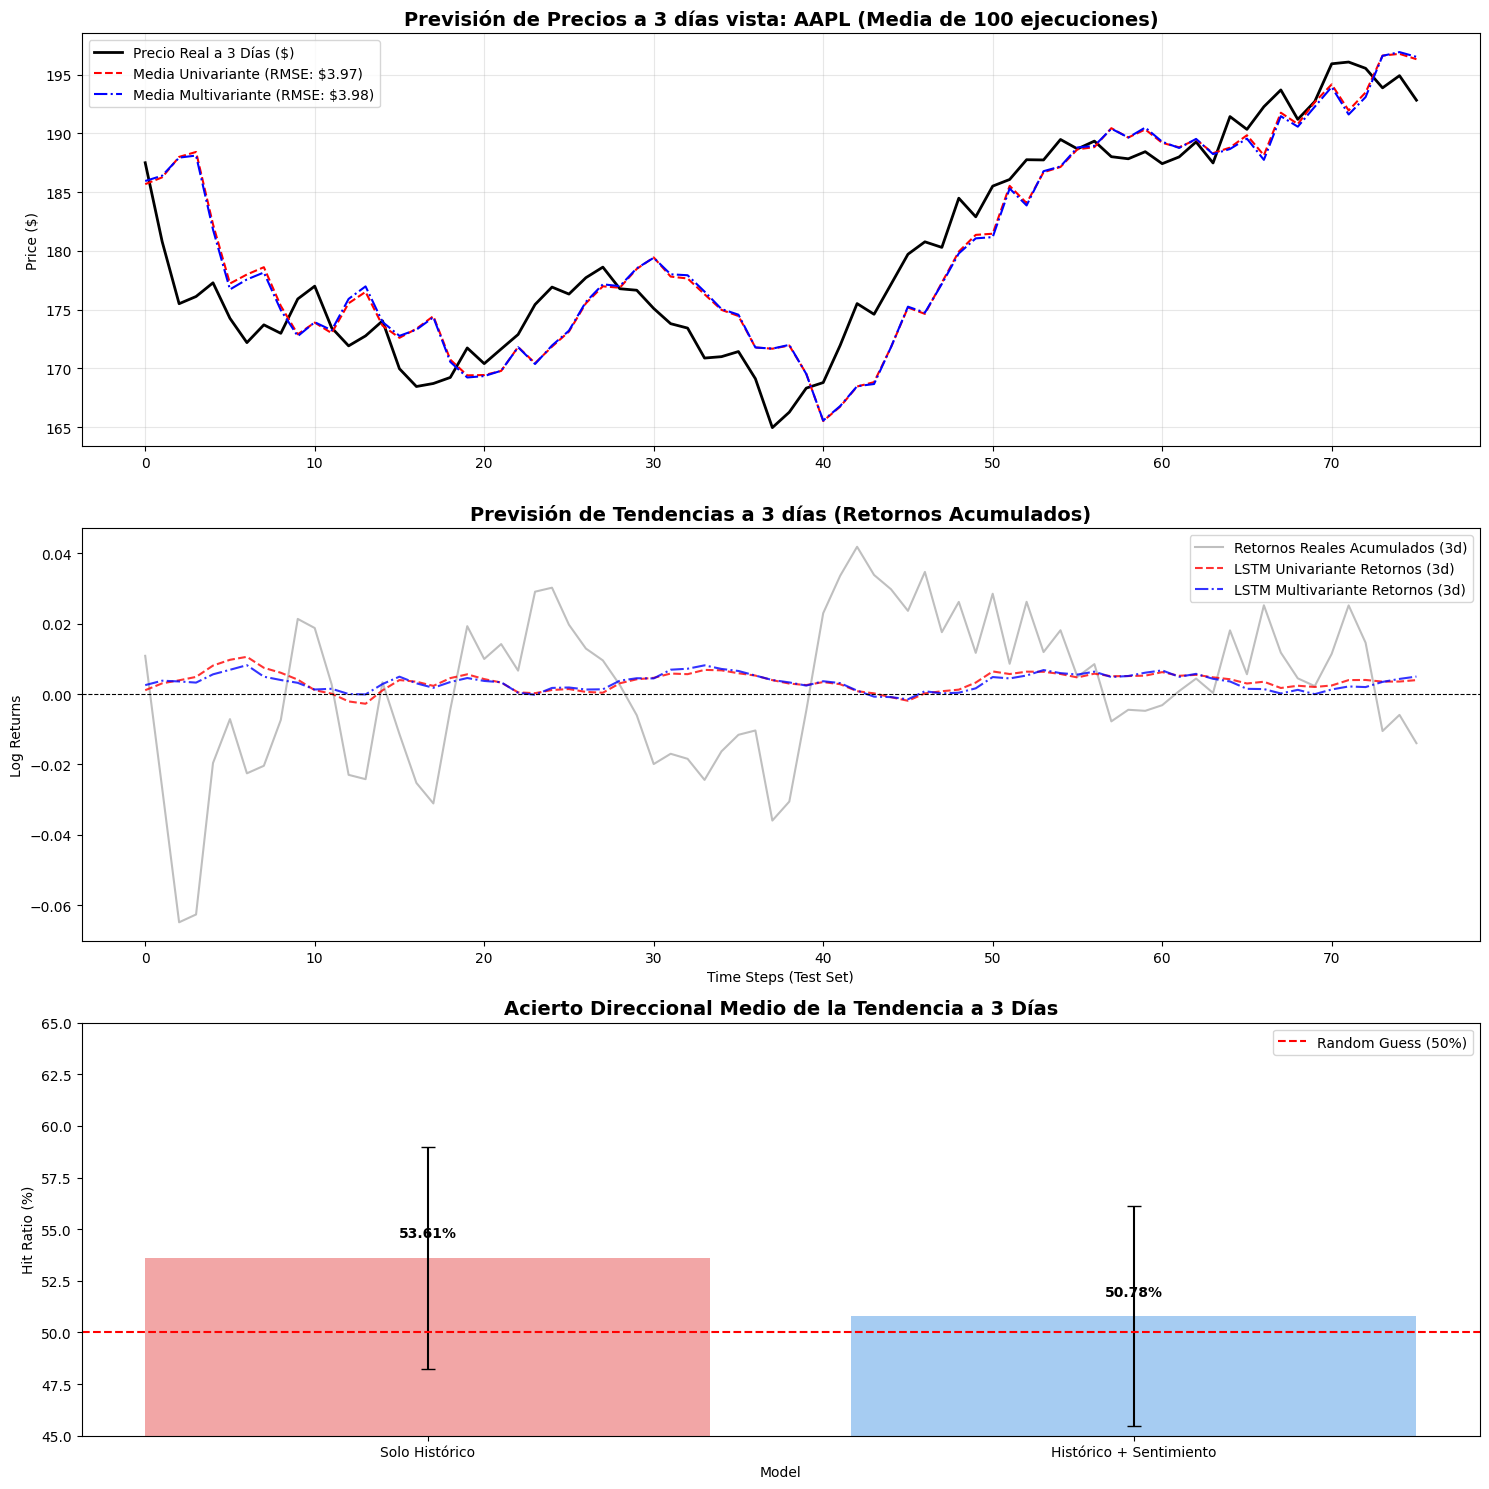

In [ ]:
experimento_lstm_lookahead("AAPL", n_runs=100, window_size=10, lookahead=3)

### Impacto del Horizonte de Predicción a 3 Días y Agravamiento del *Lagging*

La experimentación ampliando el horizonte de predicción de 1 a 3 días vista (*lookahead = 3*) reveló que el retraso visual de las curvas (*lagging*) no se mitiga, sino que sufre un efecto multiplicador.

- Probamos con LSTM Stateful

In [ ]:
def experimento_lstm_stateful(ticker_elegido, n_runs=10, window_size=10):
    tiempo_inicio = time.time()
    TICKER = ticker_elegido
    RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    print("="*75)
    print(f"INICIANDO ESTUDIO DE ROBUSTEZ: {n_runs} EJECUCIONES PARA {TICKER}")
    print(f"Arquitectura: LSTM STATEFUL (Memoria Continua) | Ventana: {window_size} días")
    print("="*75)

    # PREPARACIÓN DE DATOS (Volvemos a predecir a 1 día vista)
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()
    df_precios.index = df_precios.index.tz_localize(None)

    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    df_sent = pd.read_parquet(RUTA_SENTIMIENTO)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()

    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))

    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas(data_x, data_y, window):
        X, y = [], []
        for i in range(len(data_x) - window):
            X.append(data_x[i:i + window])
            y.append(data_y[i + window])
        return np.array(X), np.array(y)

    X_uni, y_uni = crear_ventanas(df_merged[['Ret_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)
    X_multi, _ = crear_ventanas(df_merged[['Ret_Scaled', 'Sent_Scaled']].values, df_merged['Ret_Scaled'].values, window_size)

    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]
    y_train, y_test = y_uni[:split], y_uni[split:]

    # 2. BUCLE DE EXPERIMENTOS (STATEFUL)
    lista_rmse_uni, lista_rmse_multi = [], []
    lista_hr_uni, lista_hr_multi = [], []

    preds_acu_uni_ret, preds_acu_multi_ret = [], []
    preds_acu_uni_usd, preds_acu_multi_usd = [], []

    # Para Stateful, el batch_size debe fijarse estáticamente.
    # Usaremos batch_size=1 para asegurar que la secuencia cronológica no se rompa nunca.
    BATCH_SIZE = 1
    EPOCHS = 5 # Bajamos epochs porque batch_size=1 entrena mucho más lento

    for i in range(n_runs):
        tf.keras.backend.clear_session()
        np.random.seed(i)
        tf.random.set_seed(i)
        random.seed(i)

        def crear_modelo_stateful(features):
            m = Sequential([
                Input(batch_shape=(BATCH_SIZE, window_size, features)),
                LSTM(50, stateful=True, return_sequences=True), Dropout(0.2),
                LSTM(50, stateful=True, return_sequences=False), Dropout(0.2),
                Dense(25), Dense(1)
            ])
            m.compile(optimizer='adam', loss='mse')
            return m

        m_uni = crear_modelo_stateful(features=1)
        m_multi = crear_modelo_stateful(features=2)

        for epoch in range(EPOCHS):
            m_uni.fit(X_train_u, y_train, batch_size=BATCH_SIZE, epochs=1, verbose=0, shuffle=False)

            for layer in m_uni.layers:
                if hasattr(layer, 'reset_states'):
                    layer.reset_states()

            m_multi.fit(X_train_m, y_train, batch_size=BATCH_SIZE, epochs=1, verbose=0, shuffle=False)

            for layer in m_multi.layers:
                if hasattr(layer, 'reset_states'):
                    layer.reset_states()

        # Predicciones
        p_u_ret = scaler_retorno.inverse_transform(m_uni.predict(X_test_u, batch_size=BATCH_SIZE, verbose=0)).flatten()
        p_m_ret = scaler_retorno.inverse_transform(m_multi.predict(X_test_m, batch_size=BATCH_SIZE, verbose=0)).flatten()
        actual_ret = scaler_retorno.inverse_transform(y_test.reshape(-1, 1)).flatten()

        # Reconstrucción a Precios
        precios_ayer = df_merged['Close'].values[-(len(p_u_ret)+1):-1]
        precio_real_hoy = df_merged['Close'].values[-len(p_u_ret):]

        p_u_usd = precios_ayer * np.exp(p_u_ret)
        p_m_usd = precios_ayer * np.exp(p_m_ret)

        preds_acu_uni_ret.append(p_u_ret)
        preds_acu_multi_ret.append(p_m_ret)
        preds_acu_uni_usd.append(p_u_usd)
        preds_acu_multi_usd.append(p_m_usd)

        lista_rmse_uni.append(np.sqrt(mean_squared_error(precio_real_hoy, p_u_usd)))
        lista_rmse_multi.append(np.sqrt(mean_squared_error(precio_real_hoy, p_m_usd)))
        lista_hr_uni.append(np.mean(np.sign(actual_ret) == np.sign(p_u_ret)) * 100)
        lista_hr_multi.append(np.mean(np.sign(actual_ret) == np.sign(p_m_ret)) * 100)

        print(f"   [Progreso] Completadas {i + 1}/{n_runs} ejecuciones...")

    # CÁLCULO DE MEDIAS Y GRÁFICAS
    media_uni_ret = np.mean(preds_acu_uni_ret, axis=0)
    media_multi_ret = np.mean(preds_acu_multi_ret, axis=0)
    media_uni_usd = np.mean(preds_acu_uni_usd, axis=0)
    media_multi_usd = np.mean(preds_acu_multi_usd, axis=0)

    tiempo_total = time.time() - tiempo_inicio
    print(f"\nExperimento completado en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s")

    fig, axes = plt.subplots(3, 1, figsize=(15, 15))
    ultimos_dias = 100

    # PRECIOS RECONSTRUIDOS
    axes[0].plot(precio_real_hoy[-ultimos_dias:], label="Precio Real ($)", color='black', linewidth=2)
    axes[0].plot(media_uni_usd[-ultimos_dias:], label=f"Media Univariante (RMSE: ${np.mean(lista_rmse_uni):.2f})", color='red', linestyle='--')
    axes[0].plot(media_multi_usd[-ultimos_dias:], label=f"Media Multivariante (RMSE: ${np.mean(lista_rmse_multi):.2f})", color='blue', linestyle='-.')
    axes[0].set_title(f"Price Forecasting Comparison: {TICKER} (LSTM STATEFUL)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Price ($)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # RETORNOS LOGARÍTMICOS
    axes[1].plot(actual_ret[-ultimos_dias:], label="Actual Log Returns", color='gray', alpha=0.5, linewidth=1.5)
    axes[1].plot(media_uni_ret[-ultimos_dias:], label="LSTM Univariante Returns", color='red', alpha=0.8, linestyle='--')
    axes[1].plot(media_multi_ret[-ultimos_dias:], label="LSTM Multivariante Returns", color='blue', alpha=0.8, linestyle='-.')
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"{TICKER} Returns Forecasting: Stateful LSTM", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Time Steps (Test Set)")
    axes[1].set_ylabel("Log Returns")
    axes[1].legend()

    # HIT RATIO
    df_bar = pd.DataFrame({
        'Model': ['Solo Histórico', 'Histórico + Sentimiento'],
        'Hit Ratio': [np.mean(lista_hr_uni), np.mean(lista_hr_multi)],
        'STD': [np.std(lista_hr_uni), np.std(lista_hr_multi)]
    })

    sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])
    axes[2].errorbar(x=[0, 1], y=df_bar['Hit Ratio'], yerr=df_bar['STD'], fmt='none', c='black', capsize=5)
    axes[2].axhline(50, color='red', linestyle='--', label="Random Guess (50%)")
    axes[2].set_title("Model Leaderboard: Directional Accuracy (Hit Ratio Medio - Stateful)", fontsize=14, fontweight='bold')
    axes[2].set_ylim(45, 60)
    axes[2].set_ylabel("Hit Ratio (%)")
    axes[2].legend()

    for i, val in enumerate(df_bar['Hit Ratio']):
        axes[2].text(i, val + 1, f"{val:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

INICIANDO ESTUDIO DE ROBUSTEZ: 10 EJECUCIONES PARA AAPL
Arquitectura: LSTM STATEFUL (Memoria Continua) | Ventana: 10 días
   [Progreso ⏱️] Completadas 1/10 ejecuciones...
   [Progreso ⏱️] Completadas 2/10 ejecuciones...
   [Progreso ⏱️] Completadas 3/10 ejecuciones...
   [Progreso ⏱️] Completadas 4/10 ejecuciones...
   [Progreso ⏱️] Completadas 5/10 ejecuciones...
   [Progreso ⏱️] Completadas 6/10 ejecuciones...
   [Progreso ⏱️] Completadas 7/10 ejecuciones...
   [Progreso ⏱️] Completadas 8/10 ejecuciones...
   [Progreso ⏱️] Completadas 9/10 ejecuciones...
   [Progreso ⏱️] Completadas 10/10 ejecuciones...

Experimento completado en 7m 57s


/tmp/ipykernel_123494/2947238633.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[2], palette=['#ff9999', '#99ccff'])


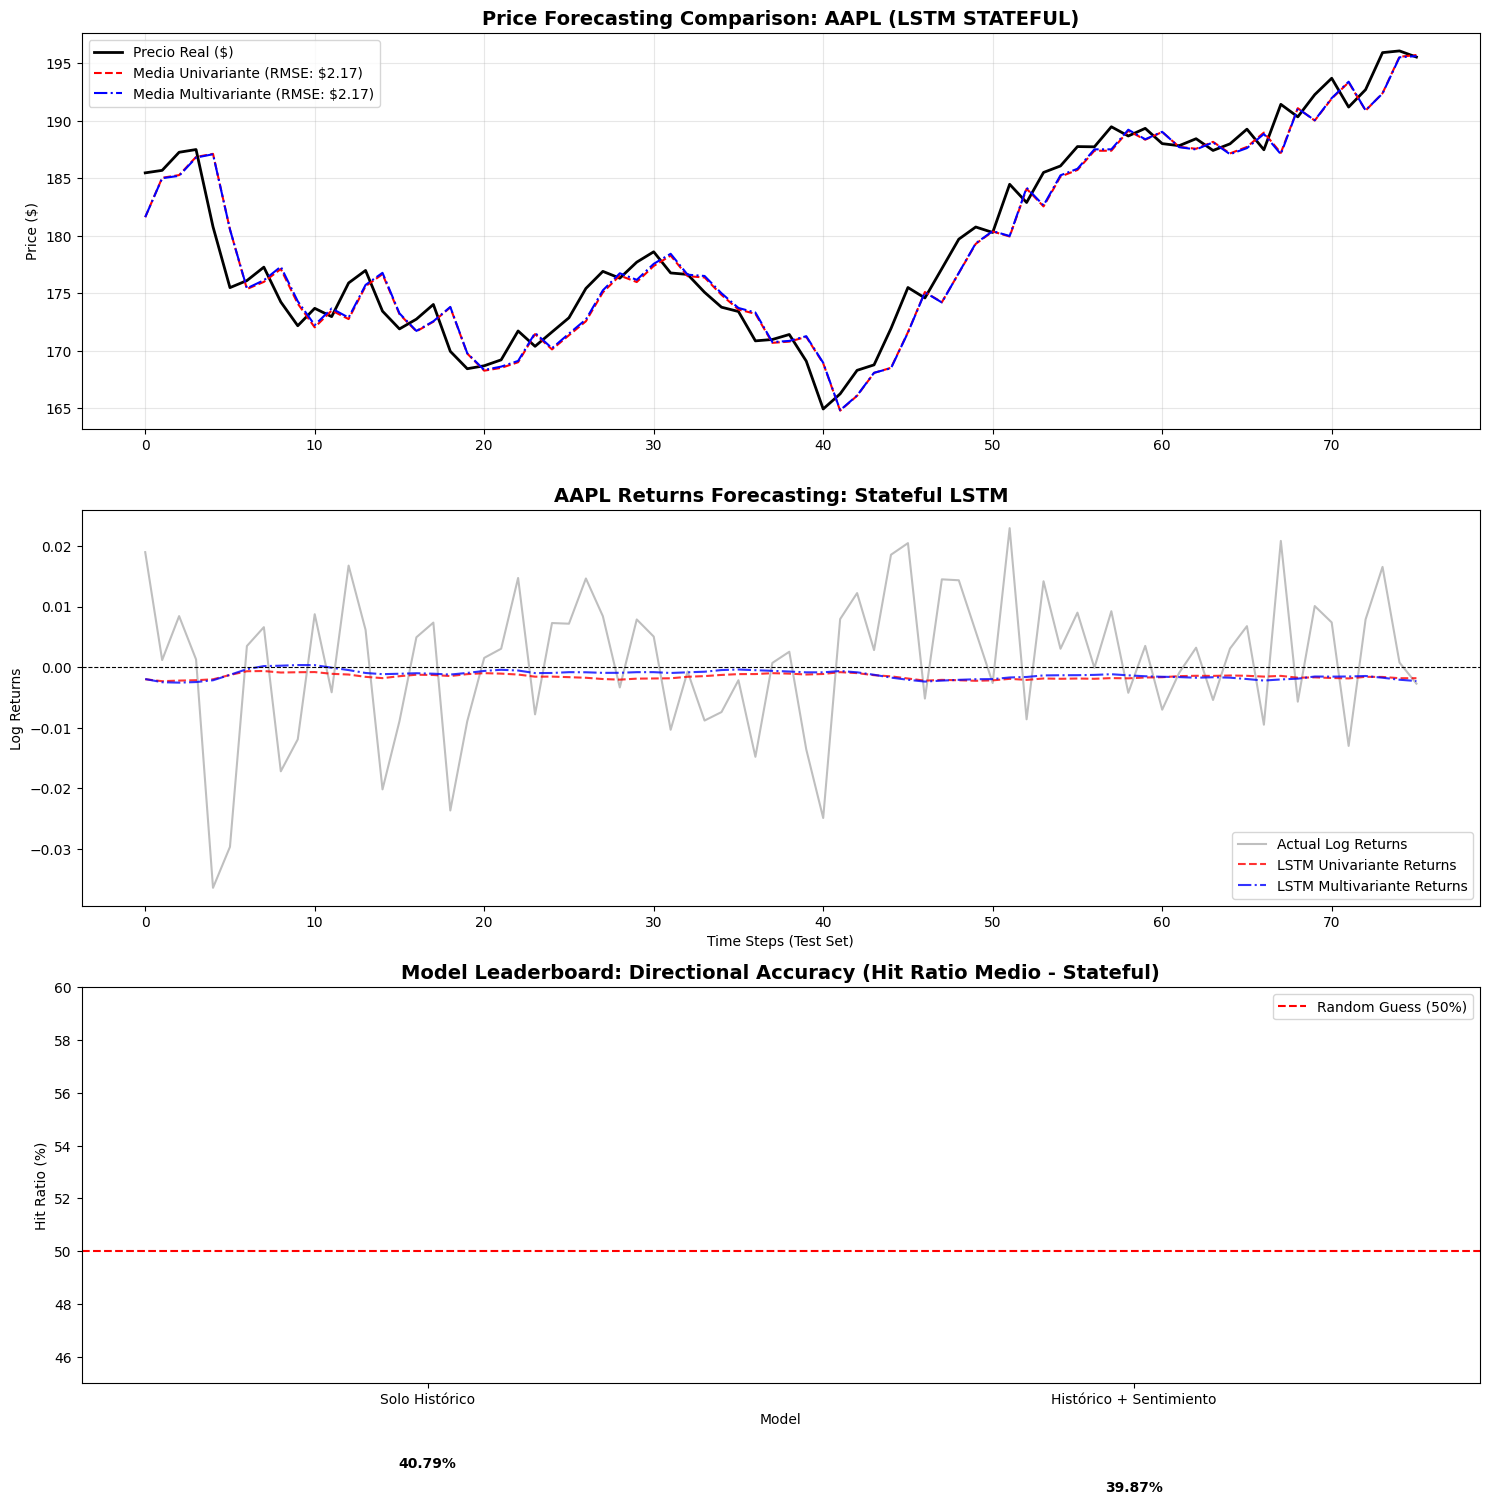

In [ ]:
experimento_lstm_stateful("AAPL", n_runs=10, window_size=10)

Al no lograr reducir este fenomeno se dispuso a cambiar el planteamiento del problema.

### Probamos con clasificación direccional

In [ ]:
def experimento_clasificacion_direccional(ticker_elegido, n_runs=100, window_size=10):
    tiempo_inicio = time.time()
    TICKER = ticker_elegido
    RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    print("="*75)
    print(f"INICIANDO ESTUDIO DE ROBUSTEZ: {n_runs} EJECUCIONES PARA {TICKER}")
    print(f"Estrategia: Clasificación Direccional (Sube=1 / Baja=0) | Ventana: {window_size} días")
    print("="*75)

    # PREPARACIÓN DE DATOS
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()
    df_precios.index = df_precios.index.tz_localize(None)

    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    # Diferenciación Direccional (Target Binario)
    # 1 si el precio sube, 0 si baja o se mantiene
    df_precios['Target_Dir'] = (df_precios['Log_Ret'] > 0).astype(int)

    df_sent = pd.read_parquet(RUTA_SENTIMIENTO)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()

    # Solo escalamos las variables de entrada (Features)
    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))

    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas_clasificacion(df, window):
        X_r, X_s, y = [], [], []
        r_vals = df['Ret_Scaled'].values
        s_vals = df['Sent_Scaled'].values
        t_vals = df['Target_Dir'].values

        for i in range(len(df) - window):
            X_r.append(r_vals[i : i + window])
            X_s.append(s_vals[i : i + window])
            y.append(t_vals[i + window])

        return np.array(X_r), np.array(X_s), np.array(y)

    X_ret, X_sent, y_targets = crear_ventanas_clasificacion(df_merged, window_size)

    X_uni = np.expand_dims(X_ret, axis=-1)
    X_multi = np.stack((X_ret, X_sent), axis=-1)

    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]
    y_train, y_test = y_targets[:split], y_targets[split:]

    # BUCLE DE EXPERIMENTOS
    lista_acc_uni, lista_acc_multi = [], []

    for i in range(n_runs):
        tf.keras.backend.clear_session()
        np.random.seed(i)
        tf.random.set_seed(i)
        random.seed(i)

        # Arquitectura adaptada para Clasificación
        def crear_modelo_clasificacion(input_shape):
            m = Sequential([
                Input(shape=input_shape),
                LSTM(50, return_sequences=True), Dropout(0.2),
                LSTM(50, return_sequences=False), Dropout(0.2),
                Dense(25),
                Dense(1, activation='sigmoid')
            ])
            m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            return m

        m_uni = crear_modelo_clasificacion((window_size, 1))
        m_uni.fit(X_train_u, y_train, batch_size=32, epochs=20, verbose=0)

        m_multi = crear_modelo_clasificacion((window_size, 2))
        m_multi.fit(X_train_m, y_train, batch_size=32, epochs=20, verbose=0)

        # Predicciones probabilísticas y conversión a clases (1 o 0)
        p_u_prob = m_uni.predict(X_test_u, verbose=0).flatten()
        p_m_prob = m_multi.predict(X_test_m, verbose=0).flatten()

        # Si la probabilidad es > 50%, predecimos Sube (1), si no Baja (0)
        p_u_class = (p_u_prob > 0.5).astype(int)
        p_m_class = (p_m_prob > 0.5).astype(int)

        # Calculamos la precisión (Hit Ratio exacto)
        acc_uni = np.mean(p_u_class == y_test) * 100
        acc_multi = np.mean(p_m_class == y_test) * 100

        lista_acc_uni.append(acc_uni)
        lista_acc_multi.append(acc_multi)

        if (i + 1) % 10 == 0:
            print(f"   [Progreso] Completadas {i + 1}/{n_runs} ejecuciones...")

    # VISUALIZACIÓN DE RESULTADOS
    tiempo_total = time.time() - tiempo_inicio
    print(f"\nExperimento completado en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Histograma de las 100 ejecuciones
    sns.kdeplot(lista_acc_uni, fill=True, color='red', label='Solo Histórico', ax=axes[0], alpha=0.5)
    sns.kdeplot(lista_acc_multi, fill=True, color='blue', label='Histórico + Sentimiento', ax=axes[0], alpha=0.5)
    axes[0].axvline(50, color='black', linestyle='--', label="Aleatorio (50%)")
    axes[0].set_title(f"Distribución del Hit Ratio en {n_runs} iteraciones", fontweight='bold')
    axes[0].set_xlabel("Hit Ratio (%)")
    axes[0].set_ylabel("Frecuencia")
    axes[0].legend()

    # Gráfica de Barras Clásica
    df_bar = pd.DataFrame({
        'Model': ['Solo Histórico', 'Histórico + Sentimiento'],
        'Hit Ratio': [np.mean(lista_acc_uni), np.mean(lista_acc_multi)],
        'STD': [np.std(lista_acc_uni), np.std(lista_acc_multi)]
    })

    sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[1], palette=['#ff9999', '#99ccff'])
    axes[1].errorbar(x=[0, 1], y=df_bar['Hit Ratio'], yerr=df_bar['STD'], fmt='none', c='black', capsize=5)
    axes[1].axhline(50, color='red', linestyle='--', label="Aleatorio (50%)")
    axes[1].set_title(f"Líder de Clasificación Direccional ({TICKER})", fontweight='bold')
    axes[1].set_ylim(45, max(df_bar['Hit Ratio']) + 3)
    axes[1].set_ylabel("Hit Ratio (%)")
    axes[1].legend()

    for i, val in enumerate(df_bar['Hit Ratio']):
        axes[1].text(i, val + 1, f"{val:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

INICIANDO ESTUDIO DE ROBUSTEZ: 100 EJECUCIONES PARA AAPL
Estrategia: Clasificación Direccional (Sube=1 / Baja=0) | Ventana: 10 días


   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 32m 31s


/tmp/ipykernel_34407/1357449244.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[1], palette=['#ff9999', '#99ccff'])


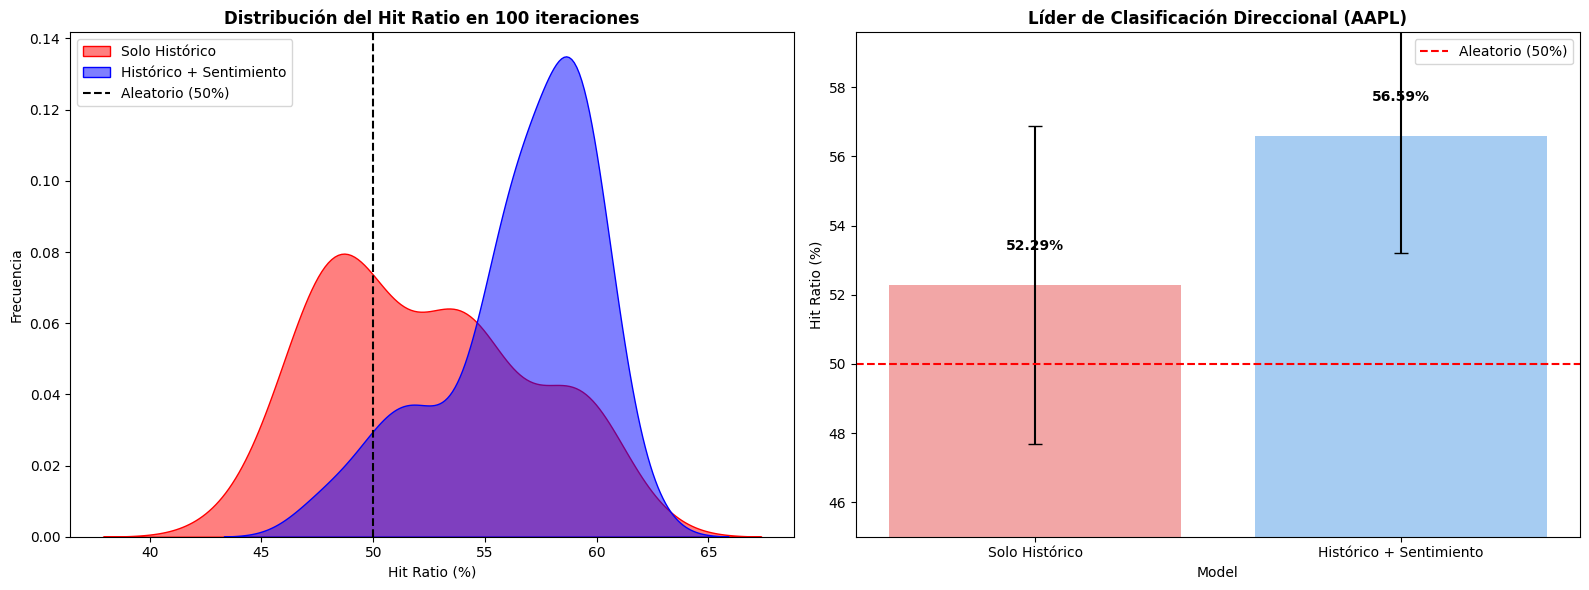

In [ ]:
experimento_clasificacion_direccional("AAPL", n_runs=100, window_size=10)

### Añadimos la simulación del mercado para observar si el lagging desaparece.

In [ ]:
def experimento_clasificacion_equity(ticker_elegido, n_runs=100, window_size=10):
    tiempo_inicio = time.time()
    TICKER = ticker_elegido
    RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    print("="*75)
    print(f"INICIANDO ESTUDIO: CLASIFICACIÓN Y CURVA DE CAPITAL PARA {TICKER}")
    print("="*75)

    # PREPARACIÓN DE DATOS
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()
    df_precios.index = df_precios.index.tz_localize(None)

    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    df_precios['Target_Dir'] = (df_precios['Log_Ret'] > 0).astype(int)

    df_sent = pd.read_parquet(RUTA_SENTIMIENTO)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()

    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))

    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas_clasificacion(df, window):
        X_r, X_s, y_dir, y_ret = [], [], [], []
        r_vals = df['Ret_Scaled'].values
        s_vals = df['Sent_Scaled'].values
        t_dir = df['Target_Dir'].values
        t_ret = df['Log_Ret'].values

        for i in range(len(df) - window):
            X_r.append(r_vals[i : i + window])
            X_s.append(s_vals[i : i + window])
            y_dir.append(t_dir[i + window])
            y_ret.append(t_ret[i + window])

        return np.array(X_r), np.array(X_s), np.array(y_dir), np.array(y_ret)

    X_ret, X_sent, y_targets_dir, y_targets_ret = crear_ventanas_clasificacion(df_merged, window_size)

    X_uni = np.expand_dims(X_ret, axis=-1)
    X_multi = np.stack((X_ret, X_sent), axis=-1)

    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]

    y_train_dir, y_test_dir = y_targets_dir[:split], y_targets_dir[split:]
    y_test_ret = y_targets_ret[split:]

    # BUCLE DE EXPERIMENTOS
    lista_acc_uni, lista_acc_multi = [], []
    curvas_cap_uni, curvas_cap_multi = [], []

    for i in range(n_runs):
        tf.keras.backend.clear_session()
        np.random.seed(i)
        tf.random.set_seed(i)
        random.seed(i)

        def crear_modelo_clasificacion(input_shape):
            m = Sequential([
                Input(shape=input_shape),
                LSTM(50, return_sequences=True), Dropout(0.2),
                LSTM(50, return_sequences=False), Dropout(0.2),
                Dense(25), Dense(1, activation='sigmoid')
            ])
            m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            return m

        m_uni = crear_modelo_clasificacion((window_size, 1))
        m_uni.fit(X_train_u, y_train_dir, batch_size=32, epochs=20, verbose=0)

        m_multi = crear_modelo_clasificacion((window_size, 2))
        m_multi.fit(X_train_m, y_train_dir, batch_size=32, epochs=20, verbose=0)

        p_u_class = (m_uni.predict(X_test_u, verbose=0).flatten() > 0.5).astype(int)
        p_m_class = (m_multi.predict(X_test_m, verbose=0).flatten() > 0.5).astype(int)

        # Hit Ratio
        lista_acc_uni.append(np.mean(p_u_class == y_test_dir) * 100)
        lista_acc_multi.append(np.mean(p_m_class == y_test_dir) * 100)

        # Simulador de Inversió
        # Multiplicamos nuestra predicción (1 o 0) por el retorno logarítmico real de ese día
        retornos_estrategia_uni = p_u_class * y_test_ret
        retornos_estrategia_multi = p_m_class * y_test_ret

        curvas_cap_uni.append(np.cumsum(retornos_estrategia_uni))
        curvas_cap_multi.append(np.cumsum(retornos_estrategia_multi))

        if (i + 1) % 10 == 0:
            print(f"   [Progreso] Completadas {i + 1}/{n_runs} ejecuciones...")

    # VISUALIZACIÓN
    tiempo_total = time.time() - tiempo_inicio
    print(f"\nExperimento completado en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s")

    fig, axes = plt.subplots(3, 1, figsize=(15, 18))

    # Histograma
    sns.kdeplot(lista_acc_uni, fill=True, color='red', label='Solo Histórico', ax=axes[0], alpha=0.5)
    sns.kdeplot(lista_acc_multi, fill=True, color='blue', label='Histórico + Sentimiento', ax=axes[0], alpha=0.5)
    axes[0].axvline(50, color='black', linestyle='--', label="Aleatorio (50%)")
    axes[0].set_title(f"Distribución del Hit Ratio en {n_runs} iteraciones", fontweight='bold')
    axes[0].set_xlabel("Hit Ratio (%)")
    axes[0].legend()

    # Gráfico de barras
    df_bar = pd.DataFrame({
        'Model': ['Solo Histórico', 'Histórico + Sentimiento'],
        'Hit Ratio': [np.mean(lista_acc_uni), np.mean(lista_acc_multi)],
        'STD': [np.std(lista_acc_uni), np.std(lista_acc_multi)]
    })
    sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[1], palette=['#ff9999', '#99ccff'])
    axes[1].errorbar(x=[0, 1], y=df_bar['Hit Ratio'], yerr=df_bar['STD'], fmt='none', c='black', capsize=5)
    axes[1].axhline(50, color='red', linestyle='--', label="Aleatorio (50%)")
    axes[1].set_title("Líder de Clasificación Direccional", fontweight='bold')
    axes[1].set_ylim(45, max(df_bar['Hit Ratio']) + 3)
    for i, val in enumerate(df_bar['Hit Ratio']):
        axes[1].text(i, val + 1, f"{val:.2f}%", ha='center', fontweight='bold')

    # CURVA DE CAPITAL
    # Calculamos la media de las curvas de capital de todas las iteraciones
    media_cap_uni = np.mean(curvas_cap_uni, axis=0) * 100 # En %
    media_cap_multi = np.mean(curvas_cap_multi, axis=0) * 100 # En %

    # Curva de capital del mercado (Buy & Hold)
    mercado_acumulado = np.cumsum(y_test_ret) * 100

    eje_x = range(len(mercado_acumulado))

    axes[2].plot(eje_x, mercado_acumulado, label="Mercado (Buy & Hold)", color='black', linewidth=2)
    axes[2].plot(eje_x, media_cap_uni, label="Estrategia: Solo Histórico", color='red', linestyle='--')
    axes[2].plot(eje_x, media_cap_multi, label="Estrategia: Histórico + Sentimiento", color='blue', linewidth=2)

    axes[2].set_title("Simulación de Inversión: Retorno Acumulado a lo largo del tiempo", fontweight='bold')
    axes[2].set_ylabel("Retorno Acumulado (%)")
    axes[2].set_xlabel("Días de Trading en el Conjunto de Test")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

INICIANDO ESTUDIO: CLASIFICACIÓN Y CURVA DE CAPITAL PARA AAPL
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 40m 12s


/tmp/ipykernel_34407/1506109605.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[1], palette=['#ff9999', '#99ccff'])


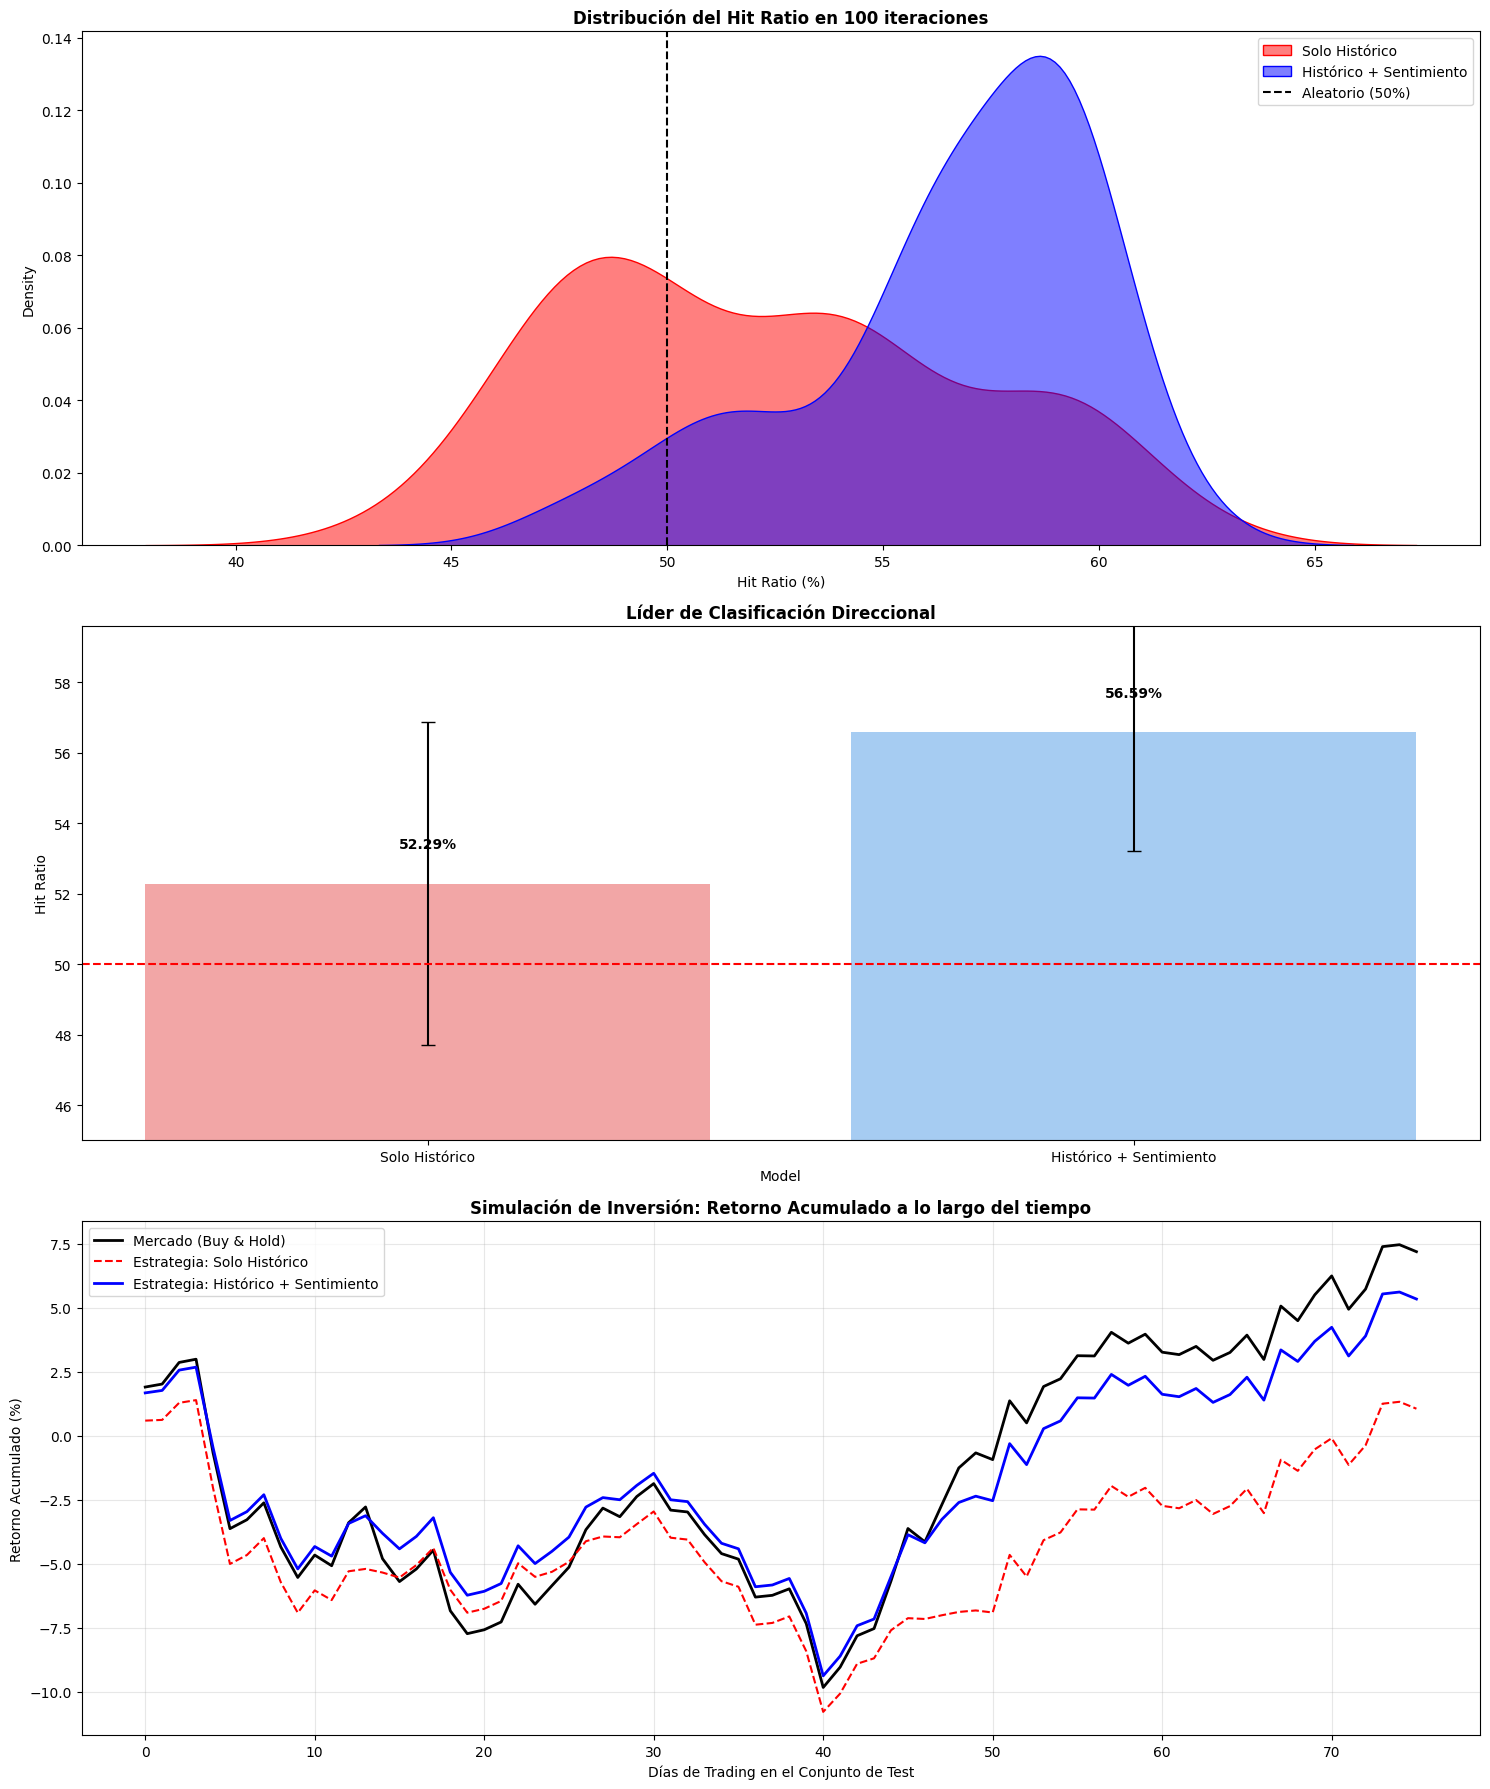

In [ ]:
experimento_clasificacion_equity("AAPL", n_runs=100, window_size=10)

Al ver estos buenos resultados se decide por volver a probar con GRU

### Probamos con GRU

In [ ]:
def experimento_clasificacion_equity_gru(ticker_elegido, n_runs=100, window_size=10):
    tiempo_inicio = time.time()
    TICKER = ticker_elegido
    RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    print("="*75)
    print(f"INICIANDO ESTUDIO FINAL: CLASIFICACIÓN CON ARQUITECTURA GRU PARA {TICKER}")
    print("="*75)

    # PREPARACIÓN DE DATOS
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()
    df_precios.index = df_precios.index.tz_localize(None)

    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    # Diferenciación Direccional
    df_precios['Target_Dir'] = (df_precios['Log_Ret'] > 0).astype(int)

    df_sent = pd.read_parquet(RUTA_SENTIMIENTO)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()

    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))

    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas_clasificacion(df, window):
        X_r, X_s, y_dir, y_ret = [], [], [], []
        r_vals = df['Ret_Scaled'].values
        s_vals = df['Sent_Scaled'].values
        t_dir = df['Target_Dir'].values
        t_ret = df['Log_Ret'].values

        for i in range(len(df) - window):
            X_r.append(r_vals[i : i + window])
            X_s.append(s_vals[i : i + window])
            y_dir.append(t_dir[i + window])
            y_ret.append(t_ret[i + window])

        return np.array(X_r), np.array(X_s), np.array(y_dir), np.array(y_ret)

    X_ret, X_sent, y_targets_dir, y_targets_ret = crear_ventanas_clasificacion(df_merged, window_size)

    X_uni = np.expand_dims(X_ret, axis=-1)
    X_multi = np.stack((X_ret, X_sent), axis=-1)

    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]

    y_train_dir, y_test_dir = y_targets_dir[:split], y_targets_dir[split:]
    y_test_ret = y_targets_ret[split:]

    # BUCLE DE EXPERIMENTOS
    lista_acc_uni, lista_acc_multi = [], []
    curvas_cap_uni, curvas_cap_multi = [], []

    for i in range(n_runs):
        tf.keras.backend.clear_session()
        np.random.seed(i)
        tf.random.set_seed(i)
        random.seed(i)

        def crear_modelo_gru(input_shape):
            m = Sequential([
                Input(shape=input_shape),
                # Sustituimos LSTM por GRU manteniendo la estructura
                GRU(50, return_sequences=True), Dropout(0.2),
                GRU(50, return_sequences=False), Dropout(0.2),
                Dense(25),
                Dense(1, activation='sigmoid') # Mantenemos clasificación
            ])
            m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            return m

        m_uni = crear_modelo_gru((window_size, 1))
        m_uni.fit(X_train_u, y_train_dir, batch_size=32, epochs=20, verbose=0)

        m_multi = crear_modelo_gru((window_size, 2))
        m_multi.fit(X_train_m, y_train_dir, batch_size=32, epochs=20, verbose=0)

        p_u_class = (m_uni.predict(X_test_u, verbose=0).flatten() > 0.5).astype(int)
        p_m_class = (m_multi.predict(X_test_m, verbose=0).flatten() > 0.5).astype(int)

        # Hit Ratio
        lista_acc_uni.append(np.mean(p_u_class == y_test_dir) * 100)
        lista_acc_multi.append(np.mean(p_m_class == y_test_dir) * 100)

        # Simulador de Inversión
        retornos_estrategia_uni = p_u_class * y_test_ret
        retornos_estrategia_multi = p_m_class * y_test_ret

        curvas_cap_uni.append(np.cumsum(retornos_estrategia_uni))
        curvas_cap_multi.append(np.cumsum(retornos_estrategia_multi))

        if (i + 1) % 10 == 0:
            print(f"   [Progreso] Completadas {i + 1}/{n_runs} ejecuciones...")

    # VISUALIZACIÓN
    tiempo_total = time.time() - tiempo_inicio
    print(f"\nExperimento GRU completado en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s")

    fig, axes = plt.subplots(3, 1, figsize=(15, 18))

    # Histograma
    sns.kdeplot(lista_acc_uni, fill=True, color='red', label='GRU Univariante', ax=axes[0], alpha=0.5)
    sns.kdeplot(lista_acc_multi, fill=True, color='blue', label='GRU Multivariante (Sentimiento)', ax=axes[0], alpha=0.5)
    axes[0].axvline(50, color='black', linestyle='--', label="Aleatorio (50%)")
    axes[0].set_title(f"Distribución del Hit Ratio con GRU ({n_runs} iteraciones)", fontweight='bold')
    axes[0].set_xlabel("Hit Ratio (%)")
    axes[0].legend()

    # Gráfico barras
    df_bar = pd.DataFrame({
        'Model': ['GRU Univariante', 'GRU Multivariante'],
        'Hit Ratio': [np.mean(lista_acc_uni), np.mean(lista_acc_multi)],
        'STD': [np.std(lista_acc_uni), np.std(lista_acc_multi)]
    })
    sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[1], palette=['#ff9999', '#99ccff'])
    axes[1].errorbar(x=[0, 1], y=df_bar['Hit Ratio'], yerr=df_bar['STD'], fmt='none', c='black', capsize=5)
    axes[1].axhline(50, color='red', linestyle='--', label="Aleatorio (50%)")
    axes[1].set_title("Líder de Clasificación Direccional (Arquitectura GRU)", fontweight='bold')
    axes[1].set_ylim(45, max(df_bar['Hit Ratio']) + 3)
    for i, val in enumerate(df_bar['Hit Ratio']):
        axes[1].text(i, val + 1, f"{val:.2f}%", ha='center', fontweight='bold')

    # CURVA DE CAPITAL
    media_cap_uni = np.mean(curvas_cap_uni, axis=0) * 100
    media_cap_multi = np.mean(curvas_cap_multi, axis=0) * 100

    mercado_acumulado = np.cumsum(y_test_ret) * 100
    eje_x = range(len(mercado_acumulado))

    axes[2].plot(eje_x, mercado_acumulado, label="Mercado (Buy & Hold)", color='black', linewidth=2)
    axes[2].plot(eje_x, media_cap_uni, label="Estrategia: GRU Univariante", color='red', linestyle='--')
    axes[2].plot(eje_x, media_cap_multi, label="Estrategia: GRU Multivariante", color='blue', linewidth=2)

    axes[2].set_title("Simulación de Inversión GRU: Retorno Acumulado a lo largo del tiempo", fontweight='bold')
    axes[2].set_ylabel("Retorno Acumulado (%)")
    axes[2].set_xlabel("Días de Trading en el Conjunto de Test")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

INICIANDO ESTUDIO FINAL: CLASIFICACIÓN CON ARQUITECTURA GRU PARA AAPL


   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento GRU completado en 38m 18s


/tmp/ipykernel_11307/3413135014.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[1], palette=['#ff9999', '#99ccff'])


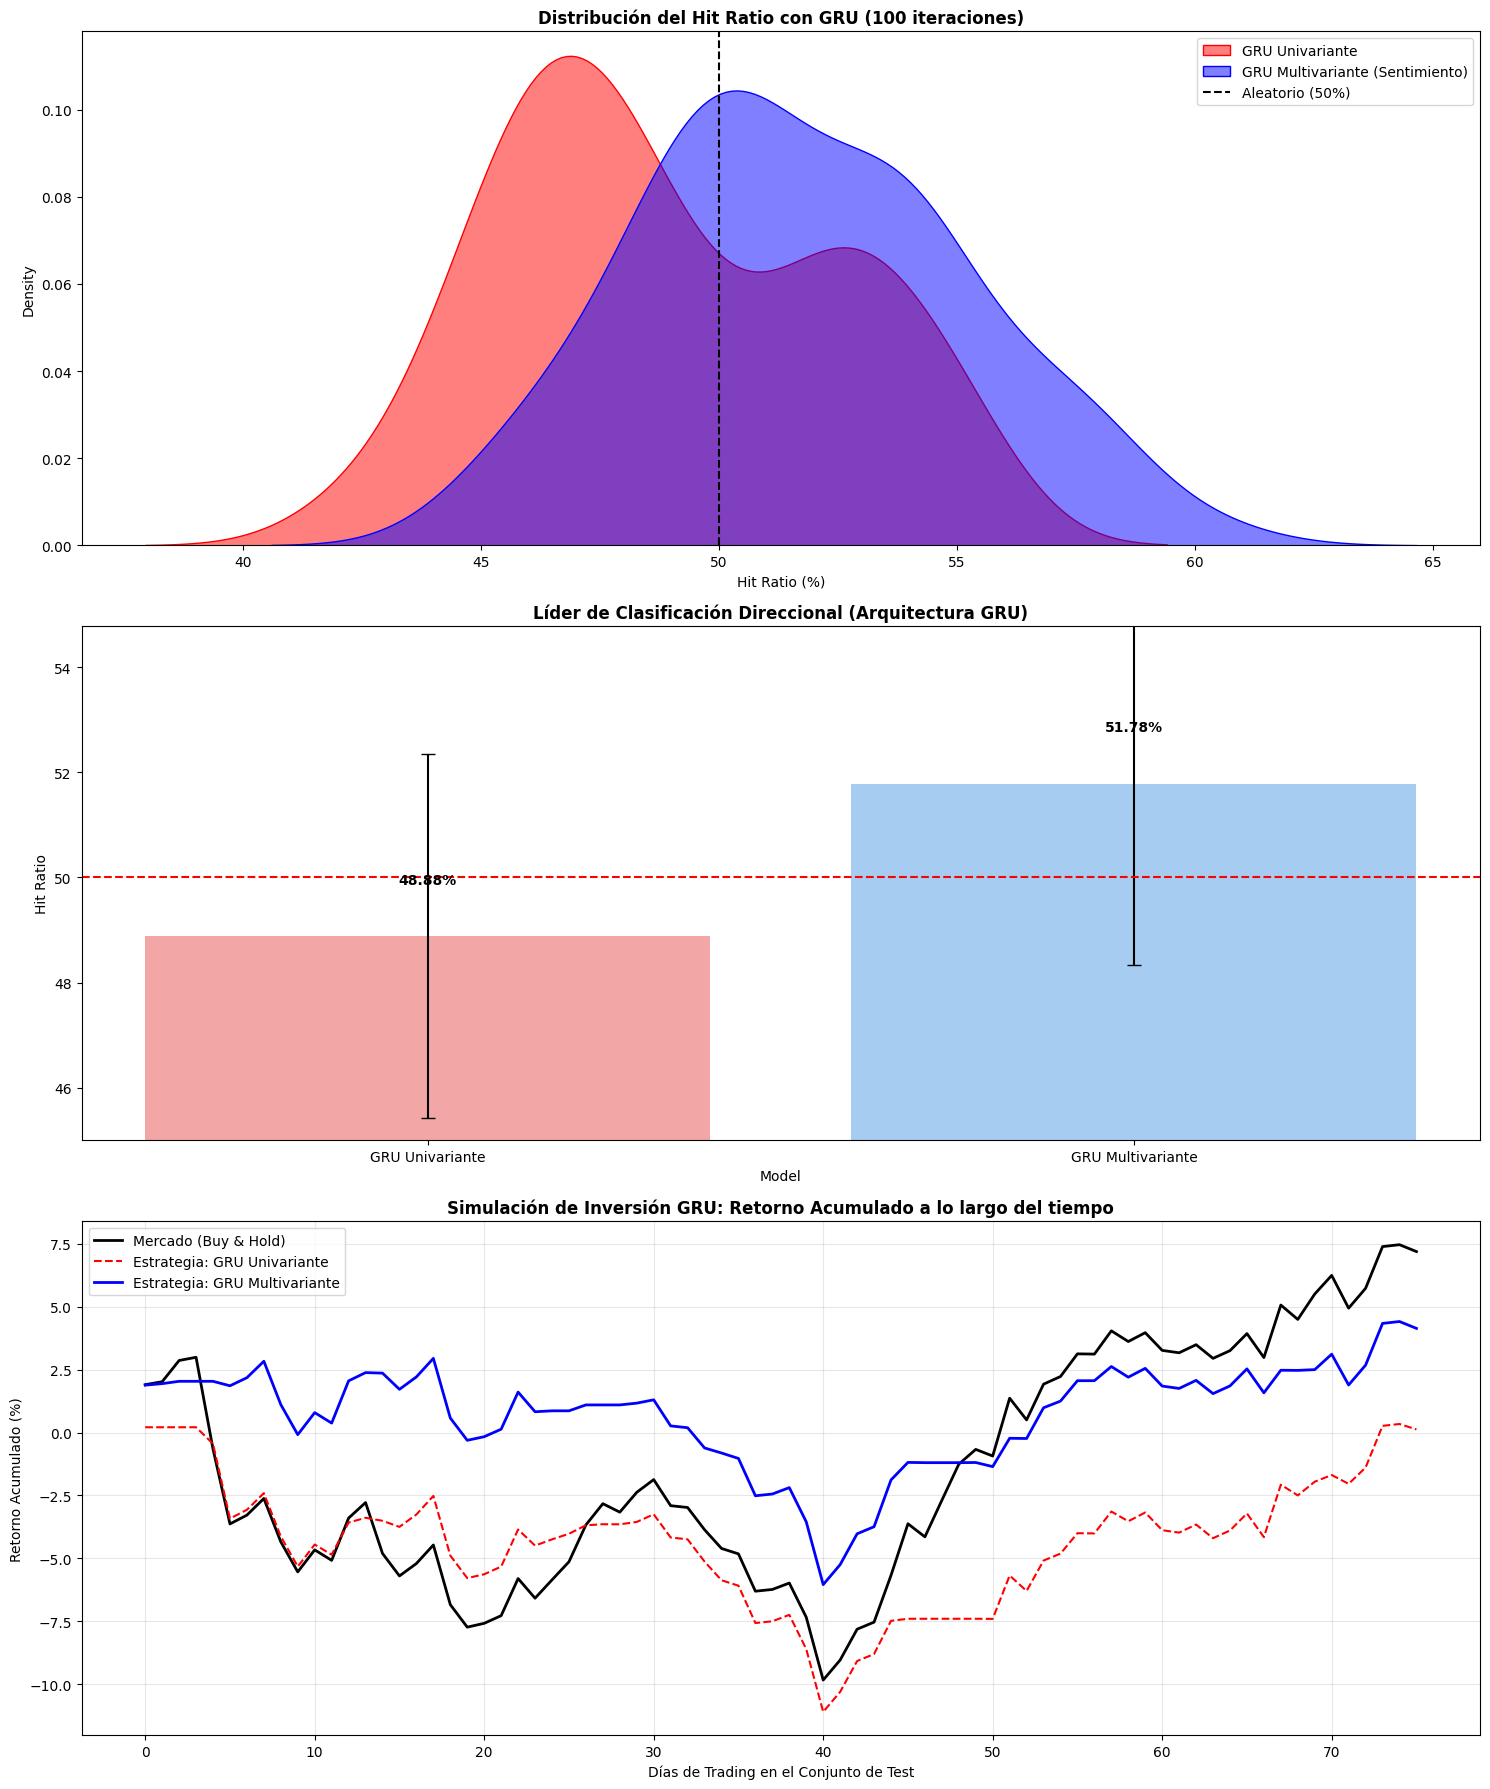

In [ ]:
experimento_clasificacion_equity_gru("AAPL", n_runs=100, window_size=10)

 Como se observa en los resultados obtenidos, el modelo se comporta mejor con el uso de LSTM que de GRU.